# Analise comparativa em conjunto entre os juizes para ver se COM RAG ou sem vale a pena

Estrutura da analise
 - RQ1. O uso de RAG melhora a qualidade percebida das respostas?

    Responder com os 5 modelos ordinais, um por dimensão. CLMM - Cumulative Link Mixed Model

 - RQ2. O efeito do RAG é consistente entre avaliadores?

    Responder com o termo de interação condition:rater.

 - RQ3. Há preferência global por respostas WITH RAG?

    Responder com o modelo logístico misto da variável binária. REG LOG


## Libs

In [1]:
## Libs
import os
import pandas as pd
import time
import matplotlib.pyplot as plt
import re
import numpy as np

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)

## Preparando a base de dados

In [3]:
## Carregando os dados
df_all_judges = pd.read_excel("/app/src/data/validacao/avaliacao_comparativa_all_judges.xlsx")
df_all_judges.head(1)

,ID,Accuracy_rag_enabled_llm_judge,Accuracy_rag_disabled_llm_judge,Completeness_rag_enabled_llm_judge,Completeness_rag_disabled_llm_judge,Adherence_rag_enabled_llm_judge,Adherence_rag_disabled_llm_judge,Utility_rag_enabled_llm_judge,Utility_rag_disabled_llm_judge,Clarity_rag_enabled_llm_judge,Clarity_rag_disabled_llm_judge,global_preference_llm_judge,Accuracy_rag_enabled_human1_judge,Accuracy_rag_disabled_human1_judge,Completeness_rag_enabled_human1_judge,Completeness_rag_disabled_human1_judge,Adherence_rag_enabled_human1_judge,Adherence_rag_disabled_human1_judge,Utility_rag_enabled_human1_judge,Utility_rag_disabled_human1_judge,Clarity_rag_enabled_human1_judge,Clarity_rag_disabled_human1_judge,global_preference_human1_judge,Accuracy_rag_enabled_human2_judge,Accuracy_rag_disabled_human2_judge,Completeness_rag_enabled_human2_judge,Completeness_rag_disabled_human2_judge,Adherence_rag_enabled_human2_judge,Adherence_rag_disabled_human2_judge,Utility_rag_enabled_human2_judge,Utility_rag_disabled_human2_judge,Clarity_rag_enabled_human2_judge,Clarity_rag_disabled_human2_judge,global_preference_human2_judge
0,1,4,3,4,3,4,3,4,3,4,4,rag_enabled,2,1,2,1,2,2,2,1,1,1,tie,5,1,3,1,5,3,3,1,5,4,rag_enabled


In [4]:
df_all_judges.columns.tolist()

['ID',
 'Accuracy_rag_enabled_llm_judge',
 'Accuracy_rag_disabled_llm_judge',
 'Completeness_rag_enabled_llm_judge',
 'Completeness_rag_disabled_llm_judge',
 'Adherence_rag_enabled_llm_judge',
 'Adherence_rag_disabled_llm_judge',
 'Utility_rag_enabled_llm_judge',
 'Utility_rag_disabled_llm_judge',
 'Clarity_rag_enabled_llm_judge',
 'Clarity_rag_disabled_llm_judge',
 'global_preference_llm_judge',
 'Accuracy_rag_enabled_human1_judge',
 'Accuracy_rag_disabled_human1_judge',
 'Completeness_rag_enabled_human1_judge',
 'Completeness_rag_disabled_human1_judge',
 'Adherence_rag_enabled_human1_judge',
 'Adherence_rag_disabled_human1_judge',
 'Utility_rag_enabled_human1_judge',
 'Utility_rag_disabled_human1_judge',
 'Clarity_rag_enabled_human1_judge',
 'Clarity_rag_disabled_human1_judge',
 'global_preference_human1_judge',
 'Accuracy_rag_enabled_human2_judge',
 'Accuracy_rag_disabled_human2_judge',
 'Completeness_rag_enabled_human2_judge',
 'Completeness_rag_disabled_human2_judge',
 'Adherence_

In [5]:
def preparar_dados_clmm(df: pd.DataFrame, id_col: str = "ID"):
    """
    Converte o dataframe wide de avaliações para:
    1) df_likert_long  -> formato longo para as 5 dimensões Likert
    2) df_pref_long    -> formato longo para preferência global binária

    Espera colunas no padrão:
      - Accuracy_rag_enabled_llm_judge
      - Accuracy_rag_disabled_human1_judge
      - ...
      - global_preference_llm_judge
      - global_preference_human1_judge
      - global_preference_human2_judge
    """

    df = df.copy()

    # -----------------------------
    # 1) Identificar colunas Likert
    # -----------------------------
    pattern_likert = re.compile(
        r"^(Accuracy|Completeness|Adherence|Utility|Clarity)_(rag_enabled|rag_disabled)_(llm_judge|human1_judge|human2_judge)$"
    )

    likert_cols = []
    for col in df.columns:
        if pattern_likert.match(col):
            likert_cols.append(col)

    # -----------------------------
    # 2) Transformar Likert -> long
    # -----------------------------
    likert_records = []

    for col in likert_cols:
        m = pattern_likert.match(col)
        dimension, condition, rater = m.groups()

        temp = df[[id_col, col]].copy()
        temp = temp.rename(columns={id_col: "question_id", col: "score"})
        temp["dimension"] = dimension
        temp["condition"] = condition
        temp["rater"] = rater

        likert_records.append(temp)

    df_likert_long = pd.concat(likert_records, ignore_index=True)

    # Ordenações úteis
    dimension_order = ["Accuracy", "Completeness", "Adherence", "Utility", "Clarity"]
    rater_order = ["human1_judge", "human2_judge", "llm_judge"]
    condition_order = ["rag_disabled", "rag_enabled"]

    df_likert_long["dimension"] = pd.Categorical(
        df_likert_long["dimension"],
        categories=dimension_order,
        ordered=True
    )

    df_likert_long["rater"] = pd.Categorical(
        df_likert_long["rater"],
        categories=rater_order,
        ordered=False
    )

    df_likert_long["condition"] = pd.Categorical(
        df_likert_long["condition"],
        categories=condition_order,
        ordered=True
    )

    # Tentar converter score para numérico
    df_likert_long["score_num"] = pd.to_numeric(df_likert_long["score"], errors="coerce")

    # Inferir categorias Likert a partir dos valores existentes
    valid_scores = sorted(df_likert_long["score_num"].dropna().unique().tolist())

    if len(valid_scores) > 0:
        df_likert_long["score_ord"] = pd.Categorical(
            df_likert_long["score_num"],
            categories=valid_scores,
            ordered=True
        )
    else:
        df_likert_long["score_ord"] = pd.Categorical(
            [],
            ordered=True
        )

    # -------------------------------------
    # 3) Identificar colunas de preferência
    # -------------------------------------
    pattern_pref = re.compile(
        r"^global_preference_(llm_judge|human1_judge|human2_judge)$"
    )

    pref_cols = []
    for col in df.columns:
        if pattern_pref.match(col):
            pref_cols.append(col)

    # -------------------------------------
    # 4) Transformar preferência -> long
    # -------------------------------------
    pref_records = []

    for col in pref_cols:
        m = pattern_pref.match(col)
        (rater,) = m.groups()

        temp = df[[id_col, col]].copy()
        temp = temp.rename(columns={id_col: "question_id", col: "preference_raw"})
        temp["rater"] = rater

        pref_records.append(temp)

    df_pref_long = pd.concat(pref_records, ignore_index=True)

    df_pref_long["rater"] = pd.Categorical(
        df_pref_long["rater"],
        categories=rater_order,
        ordered=False
    )

    # Padronizar preferência binária
    # Ajuste este mapeamento se seus valores estiverem em outro padrão
    pref_map = {
        "rag_enabled": 1,
        "rag_disabled": 0,
        "with_rag": 1,
        "without_rag": 0,
        "WITH RAG": 1,
        "WITHOUT RAG": 0,
        "A": np.nan,   # manter como NaN se A/B ainda não foi reidentificado
        "B": np.nan
    }

    df_pref_long["prefer_rag"] = df_pref_long["preference_raw"].map(pref_map)

    return df_likert_long, df_pref_long

In [6]:
df_likert_long, df_pref_long = preparar_dados_clmm(df = df_all_judges, id_col="ID")

In [7]:
df_likert_long.head()

,question_id,score,dimension,condition,rater,score_num,score_ord
0,1,4,Accuracy,rag_enabled,llm_judge,4,4
1,2,5,Accuracy,rag_enabled,llm_judge,5,5
2,3,5,Accuracy,rag_enabled,llm_judge,5,5
3,4,4,Accuracy,rag_enabled,llm_judge,4,4
4,5,4,Accuracy,rag_enabled,llm_judge,4,4


In [8]:
df_all_judges.head()


,ID,Accuracy_rag_enabled_llm_judge,Accuracy_rag_disabled_llm_judge,Completeness_rag_enabled_llm_judge,Completeness_rag_disabled_llm_judge,Adherence_rag_enabled_llm_judge,Adherence_rag_disabled_llm_judge,Utility_rag_enabled_llm_judge,Utility_rag_disabled_llm_judge,Clarity_rag_enabled_llm_judge,Clarity_rag_disabled_llm_judge,global_preference_llm_judge,Accuracy_rag_enabled_human1_judge,Accuracy_rag_disabled_human1_judge,Completeness_rag_enabled_human1_judge,Completeness_rag_disabled_human1_judge,Adherence_rag_enabled_human1_judge,Adherence_rag_disabled_human1_judge,Utility_rag_enabled_human1_judge,Utility_rag_disabled_human1_judge,Clarity_rag_enabled_human1_judge,Clarity_rag_disabled_human1_judge,global_preference_human1_judge,Accuracy_rag_enabled_human2_judge,Accuracy_rag_disabled_human2_judge,Completeness_rag_enabled_human2_judge,Completeness_rag_disabled_human2_judge,Adherence_rag_enabled_human2_judge,Adherence_rag_disabled_human2_judge,Utility_rag_enabled_human2_judge,Utility_rag_disabled_human2_judge,Clarity_rag_enabled_human2_judge,Clarity_rag_disabled_human2_judge,global_preference_human2_judge
0,1,4,3,4,3,4,3,4,3,4,4,rag_enabled,2,1,2,1,2,2,2,1,1,1,tie,5,1,3,1,5,3,3,1,5,4,rag_enabled
1,2,5,5,5,5,5,5,5,5,3,5,rag_disabled,4,2,4,2,5,5,5,4,4,4,rag_enabled,5,5,4,3,5,5,5,5,5,5,tie
2,3,5,5,5,5,4,4,5,5,5,4,tie,5,3,4,3,4,4,4,4,4,4,rag_enabled,5,5,5,5,5,5,5,5,5,5,tie
3,4,4,4,4,5,5,4,5,5,4,5,rag_disabled,5,5,4,3,4,4,4,4,4,3,rag_enabled,4,4,4,4,4,4,5,5,5,5,rag_enabled
4,5,4,2,5,3,4,2,4,3,4,3,rag_enabled,2,5,3,4,2,4,2,4,3,3,rag_disabled,1,3,1,3,3,3,1,1,3,3,tie


In [9]:
df_likert_long.tail()

,question_id,score,dimension,condition,rater,score_num,score_ord
895,26,2,Clarity,rag_disabled,human2_judge,2,2
896,27,5,Clarity,rag_disabled,human2_judge,5,5
897,28,5,Clarity,rag_disabled,human2_judge,5,5
898,29,4,Clarity,rag_disabled,human2_judge,4,4
899,30,3,Clarity,rag_disabled,human2_judge,3,3


In [10]:
df_all_judges.tail()


,ID,Accuracy_rag_enabled_llm_judge,Accuracy_rag_disabled_llm_judge,Completeness_rag_enabled_llm_judge,Completeness_rag_disabled_llm_judge,Adherence_rag_enabled_llm_judge,Adherence_rag_disabled_llm_judge,Utility_rag_enabled_llm_judge,Utility_rag_disabled_llm_judge,Clarity_rag_enabled_llm_judge,Clarity_rag_disabled_llm_judge,global_preference_llm_judge,Accuracy_rag_enabled_human1_judge,Accuracy_rag_disabled_human1_judge,Completeness_rag_enabled_human1_judge,Completeness_rag_disabled_human1_judge,Adherence_rag_enabled_human1_judge,Adherence_rag_disabled_human1_judge,Utility_rag_enabled_human1_judge,Utility_rag_disabled_human1_judge,Clarity_rag_enabled_human1_judge,Clarity_rag_disabled_human1_judge,global_preference_human1_judge,Accuracy_rag_enabled_human2_judge,Accuracy_rag_disabled_human2_judge,Completeness_rag_enabled_human2_judge,Completeness_rag_disabled_human2_judge,Adherence_rag_enabled_human2_judge,Adherence_rag_disabled_human2_judge,Utility_rag_enabled_human2_judge,Utility_rag_disabled_human2_judge,Clarity_rag_enabled_human2_judge,Clarity_rag_disabled_human2_judge,global_preference_human2_judge
25,26,3,5,3,5,3,5,3,5,3,5,rag_disabled,4,3,4,3,3,3,3,3,4,3,rag_enabled,5,2,5,2,5,3,5,1,5,2,rag_enabled
26,27,4,5,4,5,4,5,4,5,2,4,rag_disabled,4,4,5,3,4,4,4,4,5,3,rag_enabled,4,5,5,5,4,4,5,5,4,5,tie
27,28,4,5,5,5,4,5,4,5,2,5,rag_disabled,4,3,4,2,3,3,3,3,4,3,rag_enabled,5,5,5,5,5,5,5,5,5,5,tie
28,29,4,5,4,5,3,4,4,5,2,5,rag_disabled,3,4,3,2,3,3,4,4,3,4,rag_disabled,4,3,4,3,4,4,5,3,4,4,rag_enabled
29,30,3,4,4,5,3,4,3,5,2,5,rag_disabled,4,3,2,4,4,3,4,2,4,2,rag_enabled,2,2,3,2,2,2,2,2,3,3,tie


In [11]:
df_likert_long.shape

(900, 7)

In [12]:
df_pref_long.head()

,question_id,preference_raw,rater,prefer_rag
0,1,rag_enabled,llm_judge,1.0
1,2,rag_disabled,llm_judge,0.0
2,3,tie,llm_judge,NaN
3,4,rag_disabled,llm_judge,0.0
4,5,rag_enabled,llm_judge,1.0


In [13]:
df_pref_long.shape

(90, 4)

## RQ1 - O uso de RAG melhora a qualidade percebida das respostas?

In [14]:
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter
from rpy2.robjects.packages import importr

In [15]:


# carregar pacotes R
base = importr("base")
stats = importr("stats")
ordinal = importr("ordinal")


# função R que será chamada pelo Python
ro.r(
    """
    fit_clmm_py <- function(df_r, formula_str, link = "logit", nAGQ = 5) {
      df_r$question_id <- as.factor(df_r$question_id)
      df_r$rater <- stats::relevel(as.factor(df_r$rater), ref = "human1_judge")
      df_r$condition <- stats::relevel(as.factor(df_r$condition), ref = "rag_disabled")
      df_r$score_ord <- ordered(df_r$score_ord, levels = sort(unique(df_r$score_ord)))

      f <- as.formula(formula_str)

      model <- ordinal::clmm(
        formula = f,
        data = df_r,
        link = link,
        Hess = TRUE,
        nAGQ = nAGQ
      )

      sm <- summary(model)

      coef_table <- as.data.frame(sm$coefficients)
      coef_table$term <- rownames(coef_table)
      rownames(coef_table) <- NULL
      coef_table <- coef_table[, c("term", setdiff(colnames(coef_table), "term"))]

      out <- list(
        model = model,
        coef_table = coef_table,
        logLik = as.numeric(logLik(model)),
        AIC = AIC(model),
        BIC = BIC(model),
        nobs = nobs(model)
      )

      return(out)
    }
    """
)


def fit_clmm_dimension(
    df_likert_long: pd.DataFrame,
    dimension: str,
    formula: str = "score_ord ~ condition * rater + (1|question_id)",
    link: str = "logit",
    nAGQ: int = 5,
):
    required_cols = {"question_id", "rater", "condition", "dimension", "score_num"}
    missing = required_cols - set(df_likert_long.columns)
    if missing:
        raise ValueError(f"Faltam colunas obrigatórias: {sorted(missing)}")

    df_dim = (
        df_likert_long.loc[
            df_likert_long["dimension"] == dimension,
            ["question_id", "rater", "condition", "dimension", "score_num"]
        ]
        .copy()
        .dropna()
    )

    if df_dim.empty:
        raise ValueError(f"Nenhuma linha encontrada para a dimensão '{dimension}'.")

    df_dim["question_id"] = df_dim["question_id"].astype(str)
    df_dim["rater"] = df_dim["rater"].astype(str)
    df_dim["condition"] = df_dim["condition"].astype(str)
    df_dim["score_ord"] = pd.to_numeric(df_dim["score_num"], errors="coerce").astype(int)

    with localconverter(ro.default_converter + pandas2ri.converter):
        df_r = ro.conversion.py2rpy(df_dim)

    fit_fn = ro.globalenv["fit_clmm_py"]
    res = fit_fn(df_r, formula, link, nAGQ)

    with localconverter(ro.default_converter + pandas2ri.converter):
        coef_table = ro.conversion.rpy2py(res.rx2("coef_table"))

    coef_table = pd.DataFrame(coef_table).rename(
        columns={
            "Estimate": "estimate",
            "Std. Error": "std_error",
            "z value": "z_value",
            "Pr(>|z|)": "p_value",
        }
    )

    fit_stats = {
        "logLik": float(res.rx2("logLik")[0]),
        "AIC": float(res.rx2("AIC")[0]),
        "BIC": float(res.rx2("BIC")[0]),
        "nobs": int(res.rx2("nobs")[0]),
    }

    return {
        "dimension": dimension,
        "model_r": res.rx2("model"),
        "coef_table": coef_table,
        "fit_stats": fit_stats,
        "data_used": df_dim,
    }

R[write to console]: In addition: 
R[write to console]: Warning messages:

R[write to console]: 1: 
R[write to console]: In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  :
R[write to console]: 
 
R[write to console]:  library ‘/usr/lib/R/site-library’ contains no packages

R[write to console]: 2: 
R[write to console]: In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  :
R[write to console]: 
 
R[write to console]:  library ‘/usr/lib/R/site-library’ contains no packages

R[write to console]: 3: 
R[write to console]: In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  :
R[write to console]: 
 
R[write to console]:  library ‘/usr/lib/R/site-library’ contains no packages



In [16]:
# carregar pacotes R
base = importr("base")
stats = importr("stats")
ordinal = importr("ordinal")

ro.r(
    """
    fit_clmm_py <- function(df_r, formula_str, link = "logit", nAGQ = 5) {
      df_r$question_id <- as.factor(df_r$question_id)
      df_r$rater <- stats::relevel(as.factor(df_r$rater), ref = "human1_judge")
      df_r$condition <- stats::relevel(as.factor(df_r$condition), ref = "rag_disabled")
      df_r$score_ord <- ordered(df_r$score_ord, levels = sort(unique(df_r$score_ord)))

      f <- as.formula(formula_str)

      model <- ordinal::clmm(
        formula = f,
        data = df_r,
        link = link,
        Hess = TRUE,
        nAGQ = nAGQ
      )

      sm <- summary(model)

      coef_table <- as.data.frame(sm$coefficients)
      coef_table$term <- rownames(coef_table)
      rownames(coef_table) <- NULL
      coef_table <- coef_table[, c("term", setdiff(colnames(coef_table), "term"))]

      vc <- as.data.frame(vcov(model))
      vc$term_row <- rownames(vc)
      rownames(vc) <- NULL
      vc <- vc[, c("term_row", setdiff(colnames(vc), "term_row"))]

      out <- list(
        model = model,
        coef_table = coef_table,
        vcov_table = vc,
        logLik = as.numeric(logLik(model)),
        AIC = AIC(model),
        BIC = BIC(model),
        nobs = nobs(model)
      )

      return(out)
    }
    """
)

def fit_clmm_dimension(
    df_likert_long: pd.DataFrame,
    dimension: str,
    formula: str = "score_ord ~ condition * rater + (1|question_id)",
    link: str = "logit",
    nAGQ: int = 5,
):
    required_cols = {"question_id", "rater", "condition", "dimension", "score_num"}
    missing = required_cols - set(df_likert_long.columns)
    if missing:
        raise ValueError(f"Faltam colunas obrigatórias: {sorted(missing)}")

    df_dim = (
        df_likert_long.loc[
            df_likert_long["dimension"] == dimension,
            ["question_id", "rater", "condition", "dimension", "score_num"]
        ]
        .copy()
    )

    df_dim["score_ord"] = pd.to_numeric(df_dim["score_num"], errors="coerce")
    df_dim = df_dim.dropna(subset=["question_id", "rater", "condition", "score_ord"]).copy()

    if df_dim.empty:
        raise ValueError(f"Nenhuma linha encontrada para a dimensão '{dimension}'.")

    df_dim["question_id"] = df_dim["question_id"].astype(str)
    df_dim["rater"] = df_dim["rater"].astype(str)
    df_dim["condition"] = df_dim["condition"].astype(str)
    df_dim["score_ord"] = df_dim["score_ord"].astype(int)

    with localconverter(ro.default_converter + pandas2ri.converter):
        df_r = ro.conversion.py2rpy(df_dim)

    fit_fn = ro.globalenv["fit_clmm_py"]
    res = fit_fn(df_r, formula, link, nAGQ)

    with localconverter(ro.default_converter + pandas2ri.converter):
        coef_table = ro.conversion.rpy2py(res.rx2("coef_table"))
        vcov_table = ro.conversion.rpy2py(res.rx2("vcov_table"))

    coef_table = pd.DataFrame(coef_table).rename(
        columns={
            "Estimate": "estimate",
            "Std. Error": "std_error",
            "z value": "z_value",
            "Pr(>|z|)": "p_value",
        }
    )

    vcov_table = pd.DataFrame(vcov_table)

    fit_stats = {
        "logLik": float(res.rx2("logLik")[0]),
        "AIC": float(res.rx2("AIC")[0]),
        "BIC": float(res.rx2("BIC")[0]),
        "nobs": int(res.rx2("nobs")[0]),
    }

    return {
        "dimension": dimension,
        "model_r": res.rx2("model"),
        "coef_table": coef_table,
        "vcov_table": vcov_table,
        "fit_stats": fit_stats,
        "data_used": df_dim,
    }

R[write to console]: In addition: 
R[write to console]: Warning messages:

R[write to console]: 1: 
R[write to console]: In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  :
R[write to console]: 
 
R[write to console]:  library ‘/usr/lib/R/site-library’ contains no packages

R[write to console]: 2: 
R[write to console]: In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  :
R[write to console]: 
 
R[write to console]:  library ‘/usr/lib/R/site-library’ contains no packages

R[write to console]: 3: 
R[write to console]: In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  :
R[write to console]: 
 
R[write to console]:  library ‘/usr/lib/R/site-library’ contains no packages



In [17]:
def fit_clmm_all_dimensions(
    df_likert_long: pd.DataFrame,
    dimensions: list[str] | None = None,
    formula: str = "score_ord ~ condition * rater + (1|question_id)",
    link: str = "logit",
    nAGQ: int = 5,
):
    if dimensions is None:
        dimensions = ["Accuracy", "Completeness", "Adherence", "Utility", "Clarity"]

    results = {}

    for dim in dimensions:
        results[dim] = fit_clmm_dimension(
            df_likert_long=df_likert_long,
            dimension=dim,
            formula=formula,
            link=link,
            nAGQ=nAGQ,
        )

    return results

In [18]:
def consolidar_coeficientes_clmm(results_clmm: dict) -> pd.DataFrame:
    frames = []

    for dim, res in results_clmm.items():
        df_coef = res["coef_table"].copy()
        df_coef["dimension"] = dim

        # identificar cut-points
        df_coef["term_type"] = np.where(
            df_coef["term"].astype(str).str.contains(r"^\d+\|\d+$", regex=True),
            "threshold",
            "fixed_effect"
        )

        # OR e IC Wald para coeficientes individuais
        if {"estimate", "std_error"}.issubset(df_coef.columns):
            df_coef["or"] = np.exp(df_coef["estimate"])
            df_coef["ci_low"] = np.exp(df_coef["estimate"] - 1.96 * df_coef["std_error"])
            df_coef["ci_high"] = np.exp(df_coef["estimate"] + 1.96 * df_coef["std_error"])

        frames.append(df_coef)

    return pd.concat(frames, ignore_index=True)

In [19]:
from scipy.stats import norm

Human 1: efeito = conditionrag_enabled

Human 2: efeito = conditionrag_enabled + conditionrag_enabled:raterhuman2_judge

LLM judge: efeito = conditionrag_enabled + conditionrag_enabled:raterllm_judge

E o erro-padrão do efeito combinado é calculado corretamente com a matriz de variância-covariância	​


In [20]:
def _is_threshold_term(term: str) -> bool:
    """
    Identifica termos do tipo cut-point: 1|2, 2|3, ...
    """
    return bool(re.match(r"^\d+\|\d+$", str(term)))


def _prepare_fixed_effects_and_vcov(res_dim: dict):
    """
    A partir do resultado de uma dimensão, extrai:
    - vetor de coeficientes fixos
    - matriz de variância-covariância correspondente aos coeficientes fixos

    Retorna
    -------
    beta: pd.Series
        index = nome do termo
        values = estimate
    V: pd.DataFrame
        matriz vcov alinhada aos termos de beta
    """
    coef_table = res_dim["coef_table"].copy()
    vcov_table = res_dim["vcov_table"].copy()

    # manter apenas efeitos fixos substantivos + cutpoints fora
    coef_fixed = coef_table.loc[
        ~coef_table["term"].astype(str).apply(_is_threshold_term)
    ].copy()

    beta = coef_fixed.set_index("term")["estimate"].astype(float)

    # montar matriz quadrada de vcov
    # espera-se que vcov_table tenha:
    # - uma coluna 'term_row'
    # - demais colunas com nomes dos parâmetros
    if "term_row" not in vcov_table.columns:
        raise ValueError("vcov_table precisa conter a coluna 'term_row'.")

    V = vcov_table.copy()
    V = V.set_index("term_row")

    # converter tudo que for possível para numérico
    for col in V.columns:
        V[col] = pd.to_numeric(V[col], errors="coerce")

    # garantir que linhas/colunas estejam alinhadas aos coeficientes fixos
    common_terms = [t for t in beta.index if t in V.index and t in V.columns]

    if len(common_terms) == 0:
        raise ValueError(
            "Nenhum termo fixo em comum entre coef_table e vcov_table."
        )

    beta = beta.loc[common_terms]
    V = V.loc[common_terms, common_terms]

    return beta, V

In [21]:
def calcular_efeito_rag_por_avaliador(
    res_dim: dict,
    ci_level: float = 0.95
) -> pd.DataFrame:
    """
    Calcula o efeito do RAG por avaliador para UMA dimensão,
    a partir do resultado do CLMM.

    Parâmetros
    ----------
    res_dim : dict
        Saída de fit_clmm_dimension()
    ci_level : float
        Nível do intervalo de confiança

    Retorna
    -------
    pd.DataFrame com colunas:
        - dimension
        - rater
        - estimate
        - std_error
        - z_value
        - p_value
        - ci_low
        - ci_high
        - odds_ratio
        - or_ci_low
        - or_ci_high
        - interpretation
    """
    dimension = res_dim["dimension"]
    beta, V = _prepare_fixed_effects_and_vcov(res_dim)

    z_crit = norm.ppf(1 - (1 - ci_level) / 2)

    # definições dos contrastes lineares
    contrastes = {
        "human1_judge": {
            "conditionrag_enabled": 1.0
        },
        "human2_judge": {
            "conditionrag_enabled": 1.0,
            "conditionrag_enabled:raterhuman2_judge": 1.0
        },
        "llm_judge": {
            "conditionrag_enabled": 1.0,
            "conditionrag_enabled:raterllm_judge": 1.0
        }
    }

    rows = []

    for rater, weights in contrastes.items():
        # vetor L alinhado à ordem de beta
        L = pd.Series(0.0, index=beta.index)

        missing_terms = []
        for term, w in weights.items():
            if term in L.index:
                L.loc[term] = w
            else:
                missing_terms.append(term)

        # regra prática:
        # - se o termo principal do RAG não existir, não há como calcular
        # - se uma interação de um rater não existir, isso é erro do modelo esperado
        if missing_terms:
            raise ValueError(
                f"Termos ausentes para o contraste de {rater} na dimensão {dimension}: "
                f"{missing_terms}"
            )

        # estimativa linear
        estimate = float(np.dot(L.values, beta.values))

        # erro-padrão: sqrt(L' V L)
        var = float(np.dot(L.values, np.dot(V.values, L.values)))
        std_error = np.sqrt(var) if var >= 0 else np.nan

        z_value = estimate / std_error if std_error > 0 else np.nan
        p_value = 2 * (1 - norm.cdf(abs(z_value))) if pd.notna(z_value) else np.nan

        ci_low = estimate - z_crit * std_error if pd.notna(std_error) else np.nan
        ci_high = estimate + z_crit * std_error if pd.notna(std_error) else np.nan

        odds_ratio = np.exp(estimate)
        or_ci_low = np.exp(ci_low) if pd.notna(ci_low) else np.nan
        or_ci_high = np.exp(ci_high) if pd.notna(ci_high) else np.nan

        if estimate > 0:
            interpretation = "RAG associado a categorias mais altas"
        elif estimate < 0:
            interpretation = "RAG associado a categorias mais baixas"
        else:
            interpretation = "Sem efeito estimado"

        rows.append({
            "dimension": dimension,
            "rater": rater,
            "estimate": estimate,
            "std_error": std_error,
            "z_value": z_value,
            "p_value": p_value,
            "ci_low": ci_low,
            "ci_high": ci_high,
            "odds_ratio": odds_ratio,
            "or_ci_low": or_ci_low,
            "or_ci_high": or_ci_high,
            "interpretation": interpretation
        })

    return pd.DataFrame(rows)

In [22]:
def calcular_efeitos_rag_todas_dimensoes(
    results_clmm: dict,
    ci_level: float = 0.95
) -> pd.DataFrame:
    """
    Aplica calcular_efeito_rag_por_avaliador() a todas as dimensões.
    """
    frames = []

    for dim, res_dim in results_clmm.items():
        df_dim = calcular_efeito_rag_por_avaliador(
            res_dim=res_dim,
            ci_level=ci_level
        )
        frames.append(df_dim)

    return pd.concat(frames, ignore_index=True)

In [23]:
def formatar_tabela_efeitos(df: pd.DataFrame, decimals: int = 3) -> pd.DataFrame:
    out = df.copy()

    numeric_cols = [
        "estimate", "std_error", "z_value", "p_value",
        "ci_low", "ci_high",
        "odds_ratio", "or_ci_low", "or_ci_high"
    ]

    for col in numeric_cols:
        out[col] = out[col].round(decimals)

    out["or_ic95"] = (
        out["odds_ratio"].astype(str)
        + " ["
        + out["or_ci_low"].astype(str)
        + ", "
        + out["or_ci_high"].astype(str)
        + "]"
    )

    return out

In [24]:
df_likert_long.head(2)

,question_id,score,dimension,condition,rater,score_num,score_ord
0,1,4,Accuracy,rag_enabled,llm_judge,4,4
1,2,5,Accuracy,rag_enabled,llm_judge,5,5


In [25]:
df_likert_long["dimension"].unique()

['Accuracy', 'Completeness', 'Adherence', 'Utility', 'Clarity']
Categories (5, object): ['Accuracy' < 'Completeness' < 'Adherence' < 'Utility' < 'Clarity']

### rodando em uma dimensao para testar

In [26]:
# vamos filtrar a base para rodar um por modelo.
df_accuracy = df_likert_long[df_likert_long['dimension'] == 'Accuracy'].copy().reset_index(drop=True)

print("Shape Antes do filtro:", df_likert_long.shape)
print("Shape Depois do filtro:", df_accuracy.shape)

Shape Antes do filtro: (900, 7)
Shape Depois do filtro: (180, 7)


In [27]:
df_accuracy.head()

,question_id,score,dimension,condition,rater,score_num,score_ord
0,1,4,Accuracy,rag_enabled,llm_judge,4,4
1,2,5,Accuracy,rag_enabled,llm_judge,5,5
2,3,5,Accuracy,rag_enabled,llm_judge,5,5
3,4,4,Accuracy,rag_enabled,llm_judge,4,4
4,5,4,Accuracy,rag_enabled,llm_judge,4,4


In [28]:
res_accuracy = fit_clmm_dimension(df_likert_long, dimension="Accuracy")

In [29]:
res_accuracy["fit_stats"]

{'logLik': -243.85348280083736,
 'AIC': 507.7069656016747,
 'BIC': 539.6365341105768,
 'nobs': 180}

In [30]:
res_accuracy["coef_table"]

,term,estimate,std_error,z_value,p_value
1,1|2,-2.301845,0.480592,-4.789601,1.671129e-06
2,2|3,-0.644489,0.382171,-1.686389,9.172088e-02
3,3|4,0.910903,0.387823,2.348756,1.883623e-02
4,4|5,2.634690,0.436629,6.034161,1.597909e-09
5,conditionrag_enabled,0.913977,0.467886,1.953417,5.077020e-02
6,raterhuman2_judge,0.662019,0.488571,1.355009,1.754147e-01
7,raterllm_judge,2.166866,0.519893,4.167912,3.074028e-05
8,conditionrag_enabled:raterhuman2_judge,0.565044,0.681559,0.829047,4.070778e-01
9,conditionrag_enabled:raterllm_judge,-0.964762,0.670464,-1.438945,1.501660e-01


### Rodando para todas as dimensoes

In [31]:
results_clmm = fit_clmm_all_dimensions(df_likert_long)

In [32]:
tabela_coef = consolidar_coeficientes_clmm(results_clmm)
tabela_coef

,term,estimate,std_error,z_value,p_value,dimension,term_type,or,ci_low,ci_high
0,1|2,-2.301845,0.480592,-4.789601,1.671129e-06,Accuracy,threshold,0.100074,0.039015,0.256691
1,2|3,-0.644489,0.382171,-1.686389,9.172088e-02,Accuracy,threshold,0.524931,0.248194,1.110229
2,3|4,0.910903,0.387823,2.348756,1.883623e-02,Accuracy,threshold,2.486566,1.162728,5.317678
3,4|5,2.634690,0.436629,6.034161,1.597909e-09,Accuracy,threshold,13.938996,5.923321,32.801803
4,conditionrag_enabled,0.913977,0.467886,1.953417,5.077020e-02,Accuracy,fixed_effect,2.494221,0.996925,6.240331
5,raterhuman2_judge,0.662019,0.488571,1.355009,1.754147e-01,Accuracy,fixed_effect,1.938702,0.744099,5.051164
6,raterllm_judge,2.166866,0.519893,4.167912,3.074028e-05,Accuracy,fixed_effect,8.730880,3.151495,24.187973
7,conditionrag_enabled:raterhuman2_judge,0.565044,0.681559,0.829047,4.070778e-01,Accuracy,fixed_effect,1.759526,0.462638,6.691917
8,conditionrag_enabled:raterllm_judge,-0.964762,0.670464,-1.438945,1.501660e-01,Accuracy,fixed_effect,0.381074,0.102400,1.418144
9,1|2,-1.682190,0.439946,-3.823632,1.315000e-04,Completeness,threshold,0.185966,0.078514,0.440477


In [33]:
efeitos_rag_geral = calcular_efeitos_rag_todas_dimensoes(results_clmm)


In [34]:
efeitos_rag_geral.head()


,dimension,rater,estimate,std_error,z_value,p_value,ci_low,ci_high,odds_ratio,or_ci_low,or_ci_high,interpretation
0,Accuracy,human1_judge,0.913977,0.467886,1.953417,0.050770,-0.003063,1.831016,2.494221,0.996941,6.240226,RAG associado a categorias mais altas
1,Accuracy,human2_judge,1.479021,0.510312,2.898268,0.003752,0.478828,2.479214,4.388647,1.614181,11.931883,RAG associado a categorias mais altas
2,Accuracy,llm_judge,-0.050785,0.483163,-0.105109,0.916289,-0.997767,0.896197,0.950483,0.368702,2.450267,RAG associado a categorias mais baixas
3,Completeness,human1_judge,1.219486,0.477700,2.552827,0.010685,0.283211,2.155762,3.385448,1.327385,8.634463,RAG associado a categorias mais altas
4,Completeness,human2_judge,1.303174,0.491444,2.651724,0.008008,0.339962,2.266387,3.680963,1.404894,9.644494,RAG associado a categorias mais altas


In [35]:
efeitos_rag_geral_formatado = formatar_tabela_efeitos(efeitos_rag_geral)
efeitos_rag_geral_formatado.shape

(15, 13)

In [36]:
efeitos_rag_geral_formatado

,dimension,rater,estimate,std_error,z_value,p_value,ci_low,ci_high,odds_ratio,or_ci_low,or_ci_high,interpretation,or_ic95
0,Accuracy,human1_judge,0.914,0.468,1.953,0.051,-0.003,1.831,2.494,0.997,6.240,RAG associado a categorias mais altas,"2.494 [0.997, 6.24]"
1,Accuracy,human2_judge,1.479,0.510,2.898,0.004,0.479,2.479,4.389,1.614,11.932,RAG associado a categorias mais altas,"4.389 [1.614, 11.932]"
2,Accuracy,llm_judge,-0.051,0.483,-0.105,0.916,-0.998,0.896,0.950,0.369,2.450,RAG associado a categorias mais baixas,"0.95 [0.369, 2.45]"
3,Completeness,human1_judge,1.219,0.478,2.553,0.011,0.283,2.156,3.385,1.327,8.634,RAG associado a categorias mais altas,"3.385 [1.327, 8.634]"
4,Completeness,human2_judge,1.303,0.491,2.652,0.008,0.340,2.266,3.681,1.405,9.644,RAG associado a categorias mais altas,"3.681 [1.405, 9.644]"
5,Completeness,llm_judge,0.189,0.523,0.362,0.718,-0.836,1.215,1.208,0.433,3.370,RAG associado a categorias mais altas,"1.208 [0.433, 3.37]"
6,Adherence,human1_judge,0.660,0.472,1.399,0.162,-0.265,1.584,1.934,0.767,4.875,RAG associado a categorias mais altas,"1.934 [0.767, 4.875]"
7,Adherence,human2_judge,2.000,0.547,3.660,0.000,0.929,3.072,7.393,2.533,21.577,RAG associado a categorias mais altas,"7.393 [2.533, 21.577]"
8,Adherence,llm_judge,0.397,0.487,0.816,0.414,-0.557,1.351,1.488,0.573,3.863,RAG associado a categorias mais altas,"1.488 [0.573, 3.863]"
9,Utility,human1_judge,0.735,0.455,1.615,0.106,-0.157,1.627,2.086,0.855,5.089,RAG associado a categorias mais altas,"2.086 [0.855, 5.089]"


 leitura central: 

**o RAG foi avaliado de forma favorável pelos dois avaliadores humanos, mas esse padrão não foi reproduzido pelo LLM judge.**

1) Como ler a tabela

Cada linha resume o **efeito do WITH RAG versus WITHOUT RAG** em uma dimensão, para um avaliador específico.

* `estimate` é o efeito na escala de log-odds ordinal.
* `odds_ratio` é a exponenciação desse efeito.
* `OR > 1` indica que o RAG está associado a **categorias mais altas** na escala Likert.
* `OR < 1` indica associação com **categorias mais baixas**.
* o IC95% ajuda a ver a precisão da estimativa.
* quando o IC95% do OR cruza 1, o resultado não traz evidência estatística clara de efeito.

Então, para discussão substantiva, o foco principal deve estar em:

* direção do efeito;
* magnitude do OR;
* intervalo de confiança;
* consistência entre avaliadores.

1) Human 1

O padrão é **consistentemente pró-RAG** em todas as dimensões.

* **Accuracy**: OR = 2.49, IC95% [0.997, 6.24], p = 0.051
  efeito positivo, mas limítrofe.
* **Completeness**: OR = 3.39, IC95% [1.33, 8.63], p = 0.011
  evidência clara a favor do RAG.
* **Adherence**: OR = 1.93, IC95% [0.77, 4.88], p = 0.162
  direção favorável, mas sem evidência clara.
* **Utility**: OR = 2.09, IC95% [0.86, 5.09], p = 0.106
  mesma lógica.
* **Clarity**: OR = 2.67, IC95% [1.08, 6.61], p = 0.034
  evidência positiva.

**Síntese do Human 1:** o avaliador percebe melhora com RAG em todas as dimensões, com evidência mais clara em **Completeness** e **Clarity**, e um sinal também forte, mas limítrofe, em **Accuracy**.

---

2) Human 2

Aqui o padrão é ainda mais forte. Todas as estimativas são positivas, e todas as cinco dimensões têm evidência estatística.

* **Accuracy**: OR = 4.39, IC95% [1.61, 11.93], p = 0.004
* **Completeness**: OR = 3.68, IC95% [1.41, 9.64], p = 0.008
* **Adherence**: OR = 7.39, IC95% [2.53, 21.58], p < 0.001
* **Utility**: OR = 5.45, IC95% [1.92, 15.46], p = 0.001
* **Clarity**: OR = 2.78, IC95% [1.03, 7.53], p = 0.044

**Síntese do Human 2:** o RAG foi visto como claramente benéfico em todas as dimensões, com ganhos particularmente fortes em **Adherence** e **Utility**.

Aqui há uma nuance importante: o Human 2 parece mais “sensível” ao benefício do RAG do que o Human 1. Mas isso deve ser formulado com cuidado: **essa diferença entre humanos parece existir no padrão dos efeitos**, porém a afirmação formal de que Human 2 reage mais fortemente que Human 1 depende dos testes de interação no modelo original, não apenas da comparação visual dos ORs.

---

3) LLM judge

Aqui está a ruptura mais importante da análise.

* **Accuracy**: OR = 0.95, IC95% [0.37, 2.45], p = 0.916
* **Completeness**: OR = 1.21, IC95% [0.43, 3.37], p = 0.718
* **Adherence**: OR = 1.49, IC95% [0.57, 3.86], p = 0.414
* **Utility**: OR = 0.63, IC95% [0.22, 1.76], p = 0.378
* **Clarity**: OR = 0.108, IC95% [0.038, 0.308], p < 0.001

O padrão do LLM judge é muito diferente:

* em **Accuracy**, **Completeness** e **Adherence**, o efeito é essencialmente nulo;
* em **Utility**, o sinal já é negativo, embora sem evidência clara;
* em **Clarity**, há uma penalização forte e estatisticamente muito clara do RAG.

**Síntese do LLM judge:** ele não confirma os ganhos percebidos pelos humanos e, na dimensão de **Clarity**, sugere um efeito fortemente desfavorável ao RAG.


3) O que isso significa substantivamente

A leitura substantiva mais forte é esta:

3.1) Para humanos, o RAG parece agregar valor

Os dois avaliadores humanos convergem na direção do efeito:

* todos os ORs são maiores que 1;
* nenhuma dimensão humana aponta efeito negativo;
* o Human 2 encontra evidência positiva em todas as dimensões;
* o Human 1 encontra evidência clara em parte delas e sinal favorável nas demais.

Isso sustenta uma narrativa de que, **sob avaliação humana, o RAG melhorou a qualidade percebida das respostas**.

3.2) O benefício não é uniforme entre dimensões

O ganho humano parece mais forte em:

* **Completeness**
* **Adherence**
* **Utility**
* e, em menor grau, **Clarity** e **Accuracy**

Especialmente no Human 2, **Adherence** e **Utility** se destacam com ORs muito altos. Isso faz bastante sentido substantivo para RAG: quando há recuperação de contexto documental, é plausível que a resposta fique mais:

* alinhada à base normativa/documental;
* útil para consulta;
* mais completa.

3.3) O LLM judge parece aplicar outro critério de qualidade

O ponto mais interessante do estudo está aqui. O LLM judge:

* não replicou o padrão dos humanos;
* não identificou ganhos claros nas dimensões técnicas;
* e penalizou fortemente **Clarity** com RAG.

Isso sugere que o LLM judge pode estar operando com uma noção de qualidade diferente da dos especialistas humanos. Uma hipótese plausível é que respostas com RAG, por serem mais ancoradas, cautelosas ou documentais, possam soar menos “limpas” ou menos fluidas, e isso impactar a dimensão de clareza no julgamento automatizado.

Essa hipótese não deve ser apresentada como fato consumado, mas como interpretação plausível dos resultados.



4)  análise de concordância anterior

Os resultados do CLMM concordam com:

* a concordância observada foi baixa;
* o acordo corrigido pelo acaso foi apenas modesto;
* e a concordância global dependeu fortemente da métrica.

Agora o CLMM mostra **por que** isso estava acontecendo:
não se trata apenas de ruído de julgamento; há evidência de que **os avaliadores estão reagindo de maneira substantivamente diferente ao efeito do RAG**.

Então há uma integração muito boa entre as duas partes do estudo:

* **as métricas de concordância** mostraram que os avaliadores não eram intercambiáveis;
* **o CLMM** mostra que essa não-intercambialidade aparece também na direção e magnitude do efeito do RAG.

Essa é uma contribuição metodológica forte do paper.

---

5) O que eu diria como mensagem central dos resultados até agora

Eu formularia algo próximo disto:

> Os modelos ordinais mistos indicaram que, sob avaliação humana, o uso de RAG esteve consistentemente associado a notas mais altas nas cinco dimensões analisadas, com evidência mais forte para completude, aderência e utilidade. Em contraste, o LLM judge não reproduziu esse padrão, apresentando efeitos próximos de zero na maioria das dimensões e uma associação fortemente negativa em clareza. Em conjunto, os resultados sugerem que a avaliação da efetividade do RAG é sensível ao perfil do avaliador, especialmente quando juízes humanos são comparados a um juiz automatizado baseado em LLM.

---

 6) Pontos que merecem cautela na redação

Há quatro cuidados importantes.

6.1. Não dizer que “Human 2 foi maior que Human 1” como conclusão formal

Você pode dizer que **o padrão estimado** foi mais forte no Human 2.
Mas afirmar diferença formal entre os dois exige reportar explicitamente os termos de interação ou contrastes entre avaliadores.


6.3. Olhar a largura dos intervalos

Alguns ICs são largos, especialmente em Human 2 para **Adherence** e **Utility**.
Isso indica efeito potencialmente forte, mas com alguma imprecisão, o que é esperado com 30 perguntas.

6.4. Não tratar o LLM judge como “verdade”

Os resultados atuais sugerem justamente o contrário: ele parece ser um avaliador com comportamento próprio, e não um substituto neutro dos humanos.

---





7) Leitura por dimensão


* **Accuracy**: humanos pró-RAG; LLM neutro.
* **Completeness**: humanos claramente pró-RAG; LLM levemente positivo, mas sem evidência.
* **Adherence**: efeito especialmente forte para Human 2; humanos favoráveis; LLM sem evidência clara.
* **Utility**: humanos favoráveis, especialmente Human 2; LLM com inclinação negativa, mas incerta.
* **Clarity**: humanos favoráveis; LLM fortemente contrário.

Essa última é provavelmente a dimensão mais interessante do paper, porque mostra uma inversão qualitativa entre julgamento humano e automatizado.

---

8)  conclusão provisória seria:

**Até aqui, o estudo sugere que o RAG melhora a qualidade percebida das respostas quando julgado por especialistas humanos, mas essa melhora não é confirmada pelo LLM judge, que apresenta padrão divergente e penaliza fortemente a clareza. Logo, a conclusão sobre a efetividade do RAG depende materialmente de quem avalia.**

Isso é um resultado forte, coerente com a baixa concordância entre avaliadores, e metodologicamente interessante.

O próximo passo natural é transformar essa leitura em texto de **Resultados** e depois em uma **Discussão** já no tom de manuscrito.


##### Resultados: Efeito do RAG nas avaliações ordinais

Para examinar o efeito do uso de RAG sobre a qualidade percebida das respostas, ajustamos um cumulative link mixed model (CLMM) separadamente para cada dimensão avaliada. Em todos os modelos, a variável resposta foi a nota ordinal atribuída à resposta, e os preditores incluíram a condição experimental (WITH RAG vs. WITHOUT RAG), o avaliador e sua interação, com intercepto aleatório por pergunta. Os efeitos foram resumidos em odds ratios (OR), de modo que valores acima de 1 indicam associação entre RAG e categorias mais altas da escala Likert.

De forma geral, os resultados mostraram um padrão consistente de favorecimento ao RAG entre os avaliadores humanos, mas esse padrão não foi reproduzido pelo LLM judge. Para o Human 1, todas as estimativas apresentaram direção positiva, sugerindo associação entre RAG e avaliações mais altas em todas as dimensões. Esse efeito foi mais claro em Completeness (OR = 3.39; IC95% [1.33, 8.63]; p = 0.011) e Clarity (OR = 2.67; IC95% [1.08, 6.61]; p = 0.034), enquanto Accuracy apresentou efeito positivo limítrofe (OR = 2.49; IC95% [0.997, 6.24]; p = 0.051). Para Adherence (OR = 1.93; IC95% [0.77, 4.88]; p = 0.162) e Utility (OR = 2.09; IC95% [0.86, 5.09]; p = 0.106), a direção do efeito também foi favorável ao RAG, embora sem evidência estatística clara no nível convencional.

Para o Human 2, o padrão foi ainda mais pronunciado. Todas as cinco dimensões apresentaram associação positiva e estatisticamente significativa com a presença de RAG. Os maiores efeitos foram observados em Adherence (OR = 7.39; IC95% [2.53, 21.58]; p < 0.001) e Utility (OR = 5.45; IC95% [1.92, 15.46]; p = 0.001), seguidos de Accuracy (OR = 4.39; IC95% [1.61, 11.93]; p = 0.004), Completeness (OR = 3.68; IC95% [1.41, 9.64]; p = 0.008) e Clarity (OR = 2.78; IC95% [1.03, 7.53]; p = 0.044). Em conjunto, esses resultados indicam que, para esse avaliador, respostas geradas com RAG foram sistematicamente julgadas como superiores às respostas sem RAG em todas as dimensões consideradas.

Em contraste, o LLM judge exibiu um comportamento substancialmente diferente. Em Accuracy (OR = 0.95; IC95% [0.37, 2.45]; p = 0.916), Completeness (OR = 1.21; IC95% [0.43, 3.37]; p = 0.718) e Adherence (OR = 1.49; IC95% [0.57, 3.86]; p = 0.414), os efeitos estimados foram pequenos e estatisticamente não significativos. Em Utility, o efeito estimado foi negativo, embora ainda impreciso (OR = 0.63; IC95% [0.22, 1.76]; p = 0.378). O resultado mais marcante ocorreu em Clarity, dimensão em que o uso de RAG foi associado a avaliações substancialmente mais baixas (OR = 0.11; IC95% [0.038, 0.308]; p < 0.001). Assim, enquanto os especialistas humanos perceberam ganhos amplos associados ao RAG, o juiz automatizado não apenas deixou de reproduzir esse padrão, como penalizou fortemente a clareza das respostas com RAG.

Em síntese, os modelos ordinais indicam que o efeito do RAG depende materialmente do perfil do avaliador. Sob julgamento humano, o RAG foi sistematicamente associado a categorias mais altas da escala, especialmente em completude, aderência e utilidade. Sob julgamento automatizado, porém, esse padrão não se sustentou, sendo substituído por efeitos próximos de zero na maioria das dimensões e por uma penalização expressiva na dimensão de clareza.

#### Discussão

Os resultados sugerem que, no contexto de governança de dados em saúde, o uso de RAG tende a melhorar a qualidade percebida das respostas quando a avaliação é conduzida por especialistas humanos. Esse padrão foi particularmente claro para Completeness, Adherence e Utility, dimensões nas quais o acesso a evidências recuperadas parece ter agregado conteúdo, ancoragem documental e utilidade prática às respostas. Em um domínio fortemente regulado e dependente de normativos, manuais e diretrizes, esse resultado é substantivamente plausível: mecanismos de recuperação tendem a beneficiar justamente aspectos ligados à cobertura da resposta, aderência ao contexto documental e suporte à tomada de decisão.

Ao mesmo tempo, os resultados mostram que esse ganho não pode ser assumido como universal ou independente do avaliador. O comportamento do LLM judge divergiu do observado entre os especialistas humanos, sobretudo em Clarity, para a qual o efeito do RAG foi fortemente negativo. Esse achado sugere que o juiz automatizado pode estar operando com critérios de qualidade distintos dos empregados pelos humanos. Uma interpretação plausível é que respostas ancoradas em evidências recuperadas, embora potencialmente mais fiéis ao contexto documental, também possam se tornar mais cautelosas, densas ou menos fluídas, o que afetaria negativamente a percepção de clareza por parte de um avaliador automatizado. Nesse sentido, o resultado não deve ser lido apenas como ausência de benefício do RAG, mas também como evidência de que diferentes avaliadores privilegiam atributos diferentes ao julgar uma mesma resposta.

Essa divergência é coerente com a análise anterior de concordância entre avaliadores. As baixas taxas de acordo observado, os valores apenas modestos de concordância corrigida pelo acaso e a sensibilidade dos resultados à métrica de concordância já indicavam que os três juízes não eram intercambiáveis. O CLMM aprofunda essa leitura ao mostrar que a divergência não se resume a ruído de avaliação: ela afeta diretamente a direção e a magnitude do efeito estimado do RAG. Em outras palavras, a conclusão sobre a efetividade do RAG não depende apenas do sistema avaliado, mas também de quem avalia e de quais critérios de qualidade são priorizados no julgamento.

Do ponto de vista metodológico, esse achado tem implicações relevantes. Primeiro, ele reforça a necessidade de cautela no uso de LLM-as-a-judge como substituto direto da avaliação humana em domínios especializados. O juiz automatizado mostrou-se capaz de produzir um padrão de decisão distinto daquele observado entre especialistas humanos, o que pode levar a conclusões substantivamente diferentes sobre o mesmo sistema. Segundo, os resultados sugerem que estudos de avaliação de RAG em saúde e governança devem reportar explicitamente a variabilidade entre avaliadores, em vez de assumir que uma única fonte de julgamento — humana ou automatizada — seja suficiente para sustentar conclusões robustas.

Também é importante observar que os efeitos estimados não foram homogêneos entre os dois avaliadores humanos. Embora ambos tenham favorecido o RAG em todas as dimensões, o Human 2 apresentou magnitudes mais elevadas e evidência estatística mais consistente que o Human 1. Isso sugere que, mesmo entre especialistas, pode haver diferenças de sensibilidade ao valor agregado pelo RAG. Assim, a avaliação humana não deve ser tratada como bloco monolítico; ao contrário, ela também comporta variação interpretativa, ainda que, neste estudo, os humanos tenham convergido na direção geral do efeito.

Por fim, os resultados recomendam uma leitura equilibrada da efetividade do RAG. Seria excessivo concluir que o RAG melhora uniformemente todas as dimensões de qualidade sob qualquer critério de avaliação. Os dados apontam, antes, para um cenário mais nuançado: o RAG parece beneficiar a qualidade percebida por especialistas humanos, especialmente em dimensões ligadas a conteúdo e aderência contextual, mas esse benefício não é necessariamente reconhecido por um juiz automatizado, que pode inclusive penalizar aspectos relacionados à forma de apresentação da resposta. Essa tensão entre grounding documental e percepção de clareza constitui, por si só, um achado relevante para a literatura sobre avaliação de sistemas RAG em domínios de alta especialização.

#### Graficos de efeito do RAG por avaliador e dimensão

In [37]:
def plot_or_rag_por_dimensao_avaliador(
    df_effects: pd.DataFrame,
    figsize: tuple = (10, 8),
    title: str = "Effect of RAG on ordinal ratings by dimension and rater",
    title_fontsize: int = 14,
    subplot_title_fontsize: int = 12,
    axis_label_fontsize: int = 11,
    tick_fontsize: int = 10,
    value_fontsize: int = 9,
    marker_size: int = 8,
    line_width: float = 1.5,
    alpha_points: float = 0.95,
    use_log_scale: bool = True,
    xlim: tuple | None = None,
    show_values: bool = True,
    dimension_order: list[str] | None = None,
    rater_order: list[str] | None = None,
    dimension_map: dict | None = None,
    rater_map: dict | None = None,
):
    """
    Plota odds ratios (OR) com IC95% do efeito do RAG, por dimensão e avaliador.

    Espera um DataFrame com colunas:
        - dimension
        - rater
        - odds_ratio
        - or_ci_low
        - or_ci_high
        - p_value (opcional)

    Parâmetros
    ----------
    df_effects : pd.DataFrame
        Saída de calcular_efeitos_rag_todas_dimensoes().
    use_log_scale : bool
        Se True, usa escala log no eixo x (recomendado para OR).
    xlim : tuple | None
        Limites do eixo x. Ex:
            - escala linear: (0, 8)
            - escala log: (0.25, 8)
    """

    required_cols = {"dimension", "rater", "odds_ratio", "or_ci_low", "or_ci_high"}
    missing = required_cols - set(df_effects.columns)
    if missing:
        raise ValueError(f"Faltam colunas obrigatórias: {sorted(missing)}")

    df_plot = df_effects.copy()

    if dimension_order is None:
        dimension_order = ["Accuracy", "Completeness", "Adherence", "Utility", "Clarity"]

    if rater_order is None:
        rater_order = ["human1_judge", "human2_judge", "llm_judge"]

    if dimension_map is None:
        dimension_map = {
            "Accuracy": "Accuracy",
            "Completeness": "Completeness",
            "Adherence": "Adherence",
            "Utility": "Utility",
            "Clarity": "Clarity",
        }

    if rater_map is None:
        rater_map = {
            "human1_judge": "Human 1",
            "human2_judge": "Human 2",
            "llm_judge": "LLM judge",
        }

    df_plot["dimension"] = pd.Categorical(
        df_plot["dimension"],
        categories=dimension_order,
        ordered=True
    )
    df_plot["rater"] = pd.Categorical(
        df_plot["rater"],
        categories=rater_order,
        ordered=True
    )

    df_plot["dimension_label"] = df_plot["dimension"].map(dimension_map)
    df_plot["rater_label"] = df_plot["rater"].map(rater_map)

    n_raters = len(rater_order)
    fig, axes = plt.subplots(n_raters, 1, figsize=figsize, sharex=True)

    if n_raters == 1:
        axes = [axes]

    for ax, rater in zip(axes, rater_order):
        df_r = (
            df_plot[df_plot["rater"] == rater]
            .sort_values("dimension")
            .copy()
        )

        # garante ordem fixa das dimensões
        df_r = (
            df_r.set_index("dimension")
            .reindex(dimension_order)
            .reset_index()
        )

        df_r["dimension_label"] = df_r["dimension"].map(dimension_map)

        y = np.arange(len(df_r))
        x = pd.to_numeric(df_r["odds_ratio"], errors="coerce").to_numpy()
        ci_low = pd.to_numeric(df_r["or_ci_low"], errors="coerce").to_numpy()
        ci_high = pd.to_numeric(df_r["or_ci_high"], errors="coerce").to_numpy()

        xerr_left = np.where(np.isfinite(x) & np.isfinite(ci_low), x - ci_low, np.nan)
        xerr_right = np.where(np.isfinite(x) & np.isfinite(ci_high), ci_high - x, np.nan)

        ax.errorbar(
            x,
            y,
            xerr=[xerr_left, xerr_right],
            fmt="o",
            markersize=marker_size,
            linewidth=line_width,
            capsize=4,
            alpha=alpha_points,
        )

        # linha de referência: OR = 1
        ax.axvline(1.0, linestyle="--", linewidth=1)

        if use_log_scale:
            ax.set_xscale("log")

        if xlim is not None:
            ax.set_xlim(*xlim)

        if show_values:
            has_p = "p_value" in df_r.columns
            pvals = pd.to_numeric(df_r["p_value"], errors="coerce").to_numpy() if has_p else np.repeat(np.nan, len(df_r))

            for xi, yi, pi in zip(x, y, pvals):
                if np.isfinite(xi):
                    star = "*" if np.isfinite(pi) and pi < 0.05 else ""
                    label = f"{xi:.2f}{star}"

                    if use_log_scale:
                        text_x = xi * 1.08
                    else:
                        xr = ax.get_xlim()[1] - ax.get_xlim()[0]
                        text_x = xi + 0.03 * xr

                    ax.text(
                        text_x,
                        yi-0.1,
                        label,
                        va="center",
                        ha="left",
                        fontsize=value_fontsize,
                        clip_on=True
                    )

        ax.set_yticks(y)
        ax.set_yticklabels(df_r["dimension_label"].tolist(), fontsize=tick_fontsize)
        ax.set_ylabel("Dimension", fontsize=axis_label_fontsize)
        ax.set_title(rater_map.get(rater, str(rater)), fontsize=subplot_title_fontsize, pad=10)
        ax.grid(axis="x", linestyle="--", alpha=0.35)
        ax.invert_yaxis()

    axes[-1].set_xlabel("Odds ratio for WITH RAG vs WITHOUT RAG", fontsize=axis_label_fontsize)
    fig.suptitle(title, fontsize=title_fontsize, y=0.98)
    fig.subplots_adjust(left=0.22, right=0.95, top=0.92, bottom=0.08, hspace=0.32)

    plt.show()

In [44]:
def plot_or_rag_por_dimensao_avaliador(
    df_effects: pd.DataFrame,
    figsize: tuple = (10, 8),
    title: str = "Effect of RAG on ordinal ratings by dimension and rater",
    title_fontsize: int = 14,
    subplot_title_fontsize: int = 12,
    axis_label_fontsize: int = 11,
    tick_fontsize: int = 10,
    value_fontsize: int = 9,
    marker_size: int = 8,
    line_width: float = 1.5,
    alpha_points: float = 0.95,
    use_log_scale: bool = True,
    xlim: tuple | None = None,
    show_values: bool = True,
    dimension_order: list[str] | None = None,
    rater_order: list[str] | None = None,
    dimension_map: dict | None = None,
    rater_map: dict | None = None,
    y_pad: float = 0.35,
    set_xlabel_text = "Odds ratio for WITH RAG vs WITHOUT RAG"
):
    """
    Plota odds ratios (OR) com IC95% do efeito do RAG, por dimensão e avaliador.
    """

    required_cols = {"dimension", "rater", "odds_ratio", "or_ci_low", "or_ci_high"}
    missing = required_cols - set(df_effects.columns)
    if missing:
        raise ValueError(f"Faltam colunas obrigatórias: {sorted(missing)}")

    df_plot = df_effects.copy()

    if dimension_order is None:
        dimension_order = ["Accuracy", "Completeness", "Adherence", "Utility", "Clarity"]

    if rater_order is None:
        rater_order = ["human1_judge", "human2_judge", "llm_judge"]

    if dimension_map is None:
        dimension_map = {
            "Accuracy": "Accuracy",
            "Completeness": "Completeness",
            "Adherence": "Adherence",
            "Utility": "Utility",
            "Clarity": "Clarity",
        }

    if rater_map is None:
        rater_map = {
            "human1_judge": "Human 1",
            "human2_judge": "Human 2",
            "llm_judge": "LLM judge",
        }

    df_plot["dimension"] = pd.Categorical(
        df_plot["dimension"],
        categories=dimension_order,
        ordered=True
    )
    df_plot["rater"] = pd.Categorical(
        df_plot["rater"],
        categories=rater_order,
        ordered=True
    )

    df_plot["dimension_label"] = df_plot["dimension"].map(dimension_map)
    df_plot["rater_label"] = df_plot["rater"].map(rater_map)

    n_raters = len(rater_order)
    fig, axes = plt.subplots(n_raters, 1, figsize=figsize, sharex=True)

    if n_raters == 1:
        axes = [axes]

    for ax, rater in zip(axes, rater_order):
        df_r = (
            df_plot[df_plot["rater"] == rater]
            .sort_values("dimension")
            .copy()
        )

        df_r = (
            df_r.set_index("dimension")
            .reindex(dimension_order)
            .reset_index()
        )

        df_r["dimension_label"] = df_r["dimension"].map(dimension_map)

        y = np.arange(len(df_r))
        x = pd.to_numeric(df_r["odds_ratio"], errors="coerce").to_numpy()
        ci_low = pd.to_numeric(df_r["or_ci_low"], errors="coerce").to_numpy()
        ci_high = pd.to_numeric(df_r["or_ci_high"], errors="coerce").to_numpy()

        xerr_left = np.where(np.isfinite(x) & np.isfinite(ci_low), x - ci_low, np.nan)
        xerr_right = np.where(np.isfinite(x) & np.isfinite(ci_high), ci_high - x, np.nan)

        ax.errorbar(
            x,
            y,
            xerr=[xerr_left, xerr_right],
            fmt="o",
            markersize=marker_size,
            linewidth=line_width,
            capsize=4,
            alpha=alpha_points,
        )

        ax.axvline(1.0, linestyle="--", linewidth=1)

        if use_log_scale:
            ax.set_xscale("log")
            if xlim is not None and (xlim[0] <= 0 or xlim[1] <= 0):
                raise ValueError(
                    "Quando use_log_scale=True, xlim deve conter apenas valores positivos."
                )

        if xlim is not None:
            ax.set_xlim(*xlim)

        # folga vertical para os rótulos
        ax.set_ylim(-y_pad, len(df_r) - 1 + y_pad)

        if show_values:
            has_p = "p_value" in df_r.columns
            pvals = (
                pd.to_numeric(df_r["p_value"], errors="coerce").to_numpy()
                if has_p else np.repeat(np.nan, len(df_r))
            )

            xmin, xmax = ax.get_xlim()

            for xi, yi, pi in zip(x, y, pvals):
                xi_label = xi
                yi_label = yi
                xi = xi+0.05
                yi=yi-0.1
                if np.isfinite(xi_label):
                    star = "*" if np.isfinite(pi) and pi < 0.05 else ""
                    label = f"{xi_label:.2f}{star}"

                    # Se estiver perto da borda direita, joga o texto para a esquerda
                    if use_log_scale:
                        if xi * 1.12 >= xmax:
                            xytext = (-6, 0)
                            ha = "right"
                        else:
                            xytext = (6, 0)
                            ha = "left"
                    else:
                        xr = xmax - xmin
                        if xi + 0.04 * xr >= xmax:
                            xytext = (-6, 0)
                            ha = "right"
                        else:
                            xytext = (6, 0)
                            ha = "left"

                    ax.annotate(
                        label,
                        xy=(xi, yi),
                        xytext=xytext,
                        textcoords="offset points",
                        va="center",
                        ha=ha,
                        fontsize=value_fontsize,
                        annotation_clip=False
                    )

        ax.set_yticks(y)
        ax.set_yticklabels(df_r["dimension_label"].tolist(), fontsize=tick_fontsize)
        ax.set_ylabel("Dimension", fontsize=axis_label_fontsize)
        ax.set_title(rater_map.get(rater, str(rater)), fontsize=subplot_title_fontsize, pad=10)
        ax.grid(axis="x", linestyle="--", alpha=0.35)
        ax.invert_yaxis()

    axes[-1].set_xlabel(set_xlabel_text, fontsize=axis_label_fontsize)
    fig.suptitle(title, fontsize=title_fontsize, y=0.98)
    fig.subplots_adjust(left=0.22, right=0.95, top=0.92, bottom=0.08, hspace=0.32)

    plt.show()

Interpretacao do grafico do RAG. OR = Odds Ratio

OR > 1: WITH RAG associado a notas mais altas.

OR < 1: WITH RAG associado a notas mais baixas.

IC cruzando 1: efeito compatível com ausência de evidência clara.

In [45]:
efeitos_rag_geral_formatado.head(1)

,dimension,rater,estimate,std_error,z_value,p_value,ci_low,ci_high,odds_ratio,or_ci_low,or_ci_high,interpretation,or_ic95
0,Accuracy,human1_judge,0.914,0.468,1.953,0.051,-0.003,1.831,2.494,0.997,6.24,RAG associado a categorias mais altas,"2.494 [0.997, 6.24]"


In [46]:
# olhar os extremos
max = efeitos_rag_geral_formatado["or_ci_high"].max()
min = efeitos_rag_geral_formatado["or_ci_low"].min()
print(f"OR CI95% High Max: {max:.3f}")
print(f"OR CI95% Low Min: {min:.3f}")

# fazendo log10 para entender melhor a escala
max_log = np.log10(max)
min_log = np.log10(min)
print(f"OR CI95% High Max (log10): {max_log:.3f}")
print(f"OR CI95% Low Min (log10): {min_log:.3f}")


OR CI95% High Max: 21.577
OR CI95% Low Min: 0.038
OR CI95% High Max (log10): 1.334
OR CI95% Low Min (log10): -1.420


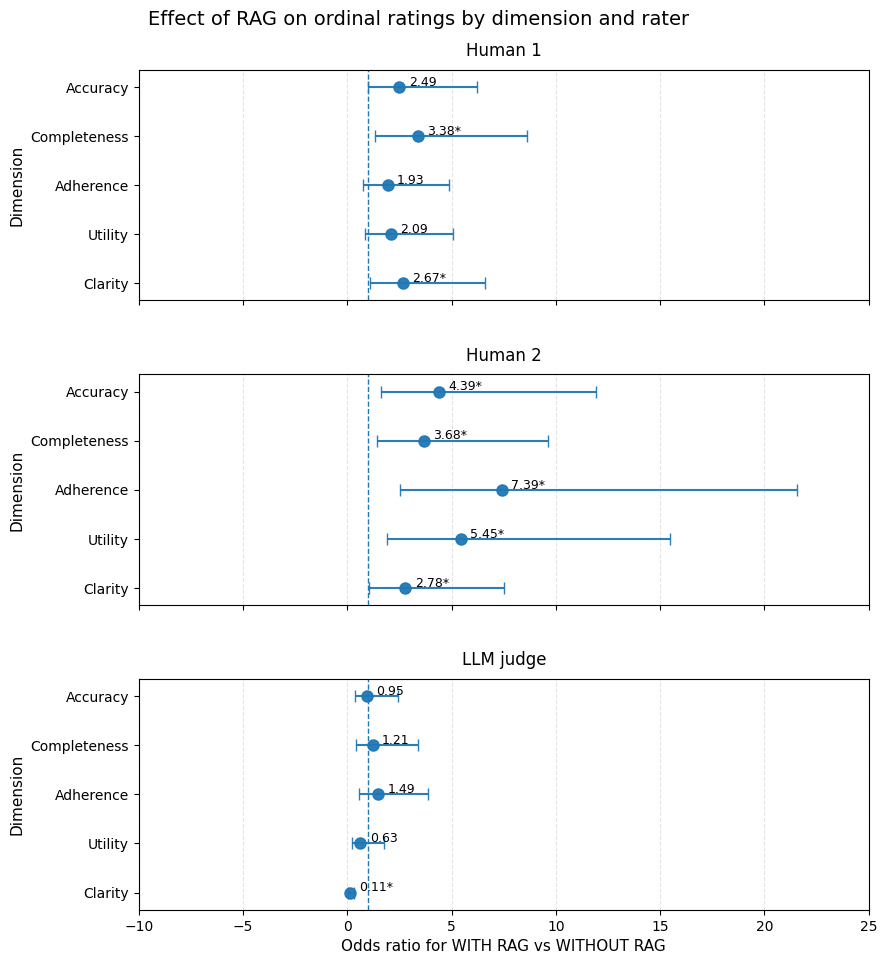

In [47]:
plot_or_rag_por_dimensao_avaliador(
    df_effects = efeitos_rag_geral_formatado,
    figsize = (10, 10),
    title = "Effect of RAG on ordinal ratings by dimension and rater",
    title_fontsize  = 14,
    subplot_title_fontsize = 12,
    axis_label_fontsize = 11,
    tick_fontsize = 10,
    value_fontsize = 9,
    marker_size = 8,
    line_width = 1.5,
    alpha_points = 0.95,
    use_log_scale = False,
    xlim = (-10,25),
    show_values = True,
    dimension_order = None,
    rater_order = None,
    dimension_map = None,
    rater_map = None
)

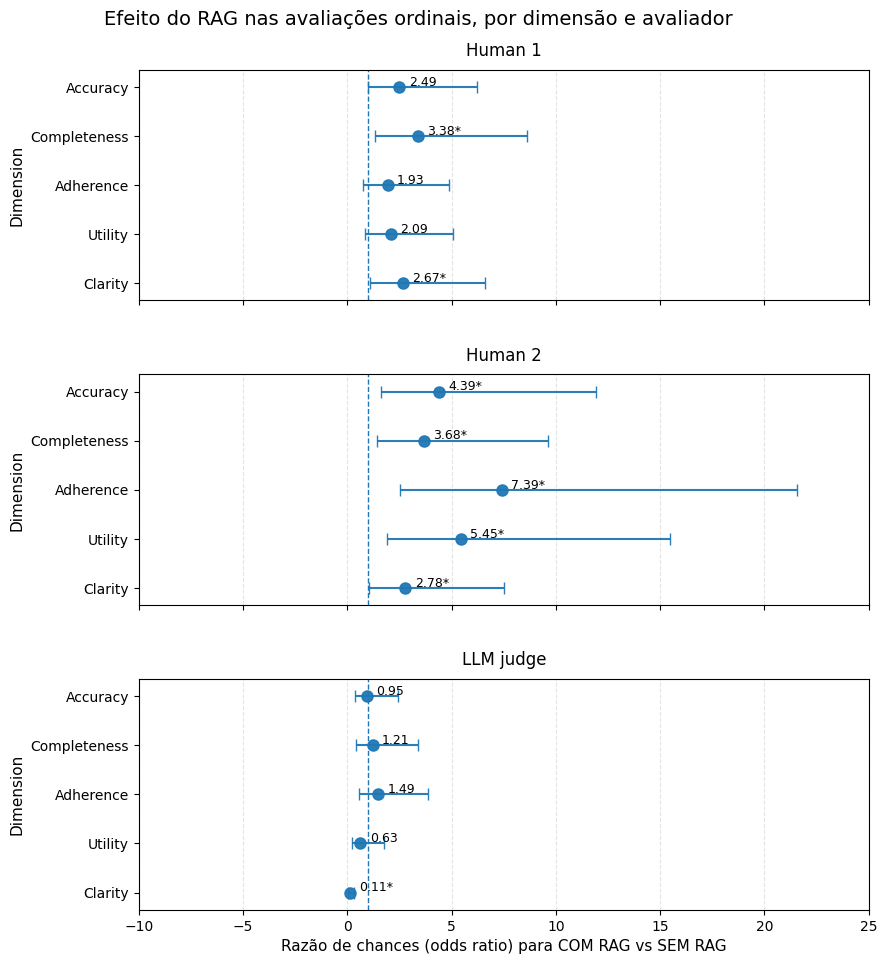

In [48]:
plot_or_rag_por_dimensao_avaliador(
    df_effects = efeitos_rag_geral_formatado,
    figsize = (10, 10),
    title = "Efeito do RAG nas avaliações ordinais, por dimensão e avaliador",
    title_fontsize  = 14,
    subplot_title_fontsize = 12,
    axis_label_fontsize = 11,
    tick_fontsize = 10,
    value_fontsize = 9,
    marker_size = 8,
    line_width = 1.5,
    alpha_points = 0.95,
    use_log_scale = False,
    xlim = (-10,25),
    show_values = True,
    dimension_order = None,
    rater_order = None,
    dimension_map = None,
    rater_map = None,
    set_xlabel_text = "Razão de chances (odds ratio) para COM RAG vs SEM RAG"
)

In [50]:
# grafico unico com as combinacoes
def plot_or_rag_single_panel(
    df_effects: pd.DataFrame,
    figsize: tuple = (11, 8),
    title: str = "Effect of RAG on ordinal ratings",
    title_fontsize: int = 14,
    axis_label_fontsize: int = 11,
    tick_fontsize: int = 10,
    value_fontsize: int = 9,
    marker_size: int = 8,
    line_width: float = 1.5,
    alpha_points: float = 0.95,
    use_log_scale: bool = True,
    xlim: tuple | None = None,
    show_values: bool = True,
    show_significance_star: bool = True,
    dimension_order: list[str] | None = None,
    rater_order: list[str] | None = None,
    dimension_map: dict | None = None,
    rater_map: dict | None = None,
    group_separator: bool = True,
    xlabel="Odds ratio for WITH RAG vs WITHOUT RAG",
    ylabel="Dimension - Rater"
):
    """
    Painel único com odds ratios (OR) e IC95% do efeito do RAG.
    Eixo y = combinação dimensão + avaliador.

    Espera colunas:
        - dimension
        - rater
        - odds_ratio
        - or_ci_low
        - or_ci_high
        - p_value (opcional)
    """

    required_cols = {"dimension", "rater", "odds_ratio", "or_ci_low", "or_ci_high"}
    missing = required_cols - set(df_effects.columns)
    if missing:
        raise ValueError(f"Faltam colunas obrigatórias: {sorted(missing)}")

    df_plot = df_effects.copy()

    if dimension_order is None:
        dimension_order = ["Accuracy", "Completeness", "Adherence", "Utility", "Clarity"]

    if rater_order is None:
        rater_order = ["human1_judge", "human2_judge", "llm_judge"]

    if dimension_map is None:
        dimension_map = {
            "Accuracy": "Accuracy",
            "Completeness": "Completeness",
            "Adherence": "Adherence",
            "Utility": "Utility",
            "Clarity": "Clarity",
        }

    if rater_map is None:
        rater_map = {
            "human1_judge": "Human 1",
            "human2_judge": "Human 2",
            "llm_judge": "LLM judge",
        }

    df_plot["dimension"] = pd.Categorical(
        df_plot["dimension"],
        categories=dimension_order,
        ordered=True
    )
    df_plot["rater"] = pd.Categorical(
        df_plot["rater"],
        categories=rater_order,
        ordered=True
    )

    df_plot["dimension_label"] = df_plot["dimension"].map(dimension_map)
    df_plot["rater_label"] = df_plot["rater"].map(rater_map)

    # Ordem final: por dimensão, depois por avaliador
    df_plot = df_plot.sort_values(["dimension", "rater"]).reset_index(drop=True)

    df_plot["y_label"] = (
        df_plot["dimension_label"].astype(str) + " - " + df_plot["rater_label"].astype(str)
    )

    y = np.arange(len(df_plot))
    x = pd.to_numeric(df_plot["odds_ratio"], errors="coerce").to_numpy()
    ci_low = pd.to_numeric(df_plot["or_ci_low"], errors="coerce").to_numpy()
    ci_high = pd.to_numeric(df_plot["or_ci_high"], errors="coerce").to_numpy()

    xerr_left = np.where(np.isfinite(x) & np.isfinite(ci_low), x - ci_low, np.nan)
    xerr_right = np.where(np.isfinite(x) & np.isfinite(ci_high), ci_high - x, np.nan)

    fig, ax = plt.subplots(figsize=figsize)

    ax.errorbar(
        x,
        y,
        xerr=[xerr_left, xerr_right],
        fmt="o",
        markersize=marker_size,
        linewidth=line_width,
        capsize=4,
        alpha=alpha_points,
    )

    # linha de referência
    ax.axvline(1.0, linestyle="--", linewidth=1)

    if use_log_scale:
        ax.set_xscale("log")

    if xlim is not None:
        ax.set_xlim(*xlim)

    # linhas separadoras entre grupos de dimensão
    if group_separator:
        group_size = len(rater_order)
        for k in range(1, len(dimension_order)):
            ax.axhline(k * group_size - 0.5, linestyle=":", linewidth=0.9, alpha=0.5)

    if show_values:
        has_p = "p_value" in df_plot.columns
        pvals = (
            pd.to_numeric(df_plot["p_value"], errors="coerce").to_numpy()
            if has_p else np.repeat(np.nan, len(df_plot))
        )

        xmin, xmax = ax.get_xlim()
        xrange_ = xmax - xmin if not use_log_scale else None

        for xi, yi, pi in zip(x, y, pvals):
            if np.isfinite(xi):
                star = "*" if show_significance_star and np.isfinite(pi) and pi < 0.05 else ""
                label = f"{xi:.2f}{star}"

                if use_log_scale:
                    text_x = xi * 1.08
                    # evita estourar à direita
                    if text_x > xmax:
                        text_x = xi / 1.08
                        ha = "right"
                    else:
                        ha = "left"
                else:
                    text_x = xi + 0.03 * xrange_
                    if text_x > xmax:
                        text_x = xi - 0.03 * xrange_
                        ha = "right"
                    else:
                        ha = "left"

                ax.text(
                    text_x,
                    yi-0.1,
                    label,
                    va="center",
                    ha=ha,
                    fontsize=value_fontsize,
                    clip_on=True
                )

    ax.set_yticks(y)
    ax.set_yticklabels(df_plot["y_label"].tolist(), fontsize=tick_fontsize)
    ax.set_xlabel(xlabel, fontsize=axis_label_fontsize)
    ax.set_ylabel(ylabel, fontsize=axis_label_fontsize)
    ax.set_title(title, fontsize=title_fontsize, pad=12)
    ax.grid(axis="x", linestyle="--", alpha=0.35)
    ax.invert_yaxis()

    plt.tight_layout()
    plt.show()

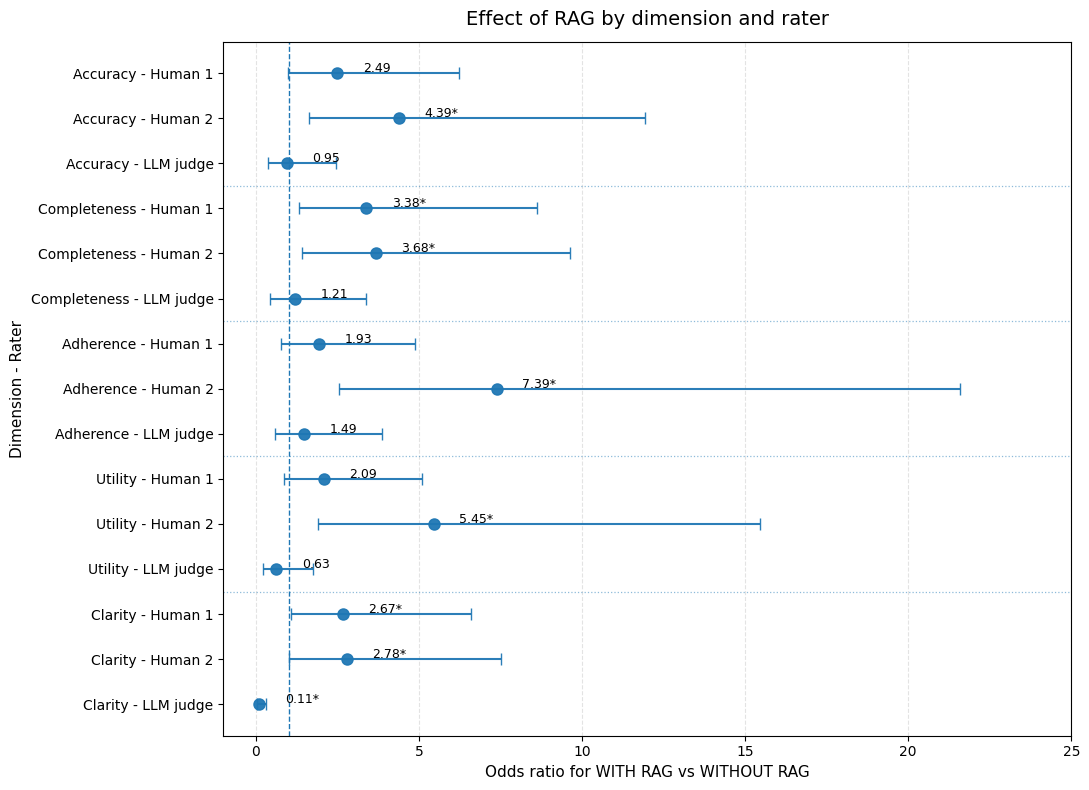

In [51]:
plot_or_rag_single_panel(
    efeitos_rag_geral_formatado,
    figsize=(11, 8),
    use_log_scale=False,
    xlim=(-1, 25),
    title="Effect of RAG by dimension and rater",
    show_values=True,
    show_significance_star=True
)

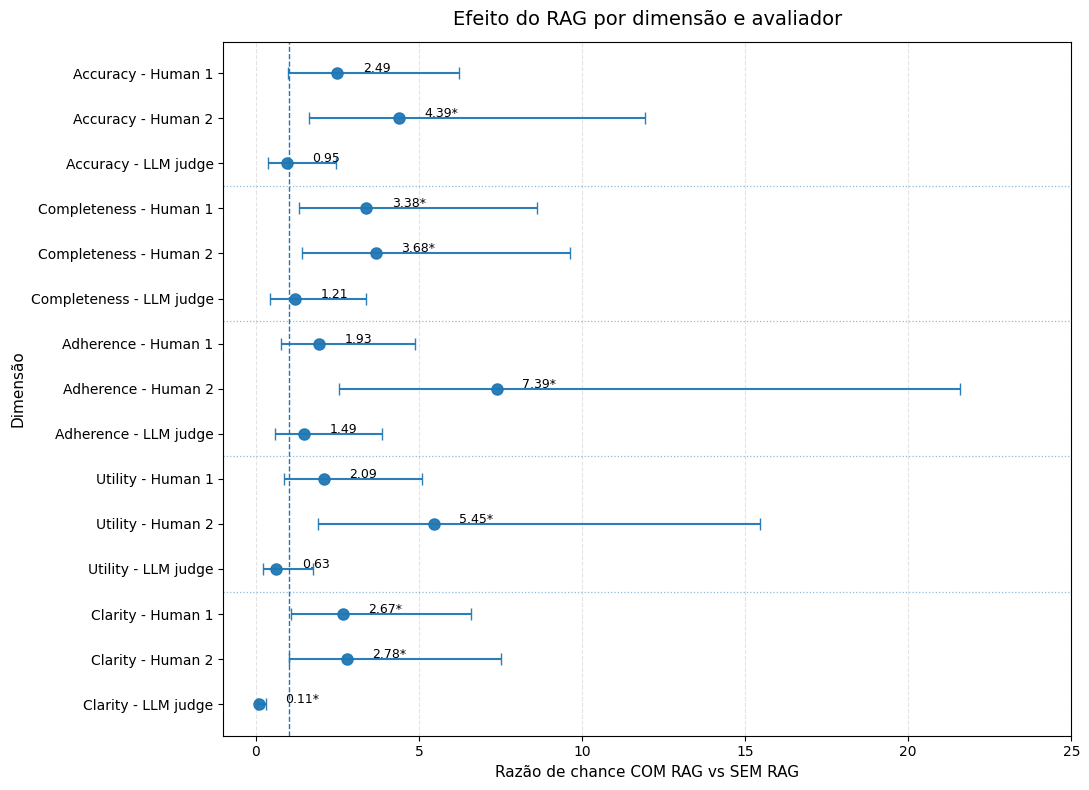

In [53]:
plot_or_rag_single_panel(
    efeitos_rag_geral_formatado,
    figsize=(11, 8),
    use_log_scale=False,
    xlim=(-1, 25),
    title="Efeito do RAG por dimensão e avaliador",
    show_values=True,
    show_significance_star=True,
    xlabel="Razão de chance COM RAG vs SEM RAG",
    ylabel="Dimensão"
)

## RQ3. Há preferência global por respostas WITH RAG? 

#### Roteiro da análise da preferência global

Nesta etapa, a variável de interesse é a **preferência global final**, registrada em três categorias: `rag_enabled`, `rag_disabled` e `tie`. Como se trata de uma resposta **categórica nominal com três níveis**, a análise foi estruturada em blocos.

Primeiro, realizamos uma **análise descritiva**, com o objetivo de entender a distribuição das preferências no conjunto total e por avaliador. Para isso, calculamos frequências absolutas e proporções e utilizamos gráficos de barras para visualizar como cada avaliador distribui suas escolhas entre as três categorias.

Em seguida, conduzimos a **análise inferencial principal** por meio de uma **regressão logística multinomial**, utilizando `rag_disabled` como categoria de referência e `human1_judge` como avaliador de referência. Essa modelagem permite comparar, em relação ao cenário sem RAG, tanto a probabilidade relativa de preferência por `rag_enabled` quanto a probabilidade relativa de ocorrência de `tie`, em função do avaliador.

Por fim, realizamos uma **análise de sensibilidade** com um modelo multinomial com **intercepto aleatório por `question_id`**, de modo a considerar explicitamente o agrupamento das avaliações por pergunta. O objetivo dessa etapa foi verificar se a dependência entre observações da mesma pergunta alteraria materialmente os efeitos estimados na análise principal.

Em conjunto, esse fluxo permite analisar a preferência global em três níveis complementares: **descrição da distribuição das escolhas**, **comparação inferencial entre avaliadores** e **verificação de robustez frente à estrutura agrupada dos dados**.


In [ ]:
df_pref_long.head(2)

In [ ]:
df_pref_long["preference_raw"].value_counts()

Vamos fazer a analise em dois blocos:

- 1. Analise descritva para entender a distribuição.
- 2. Analise inferencial: reg log multinomial

### RQ3. Item 1

In [54]:

def resumo_preferencias(df_pref_long: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Retorna dois dataframes:
    1) resumo_total: contagens e proporções no total
    2) resumo_por_avaliador: contagens e proporções por avaliador
    """

    df = df_pref_long.copy()

    # padronização opcional da ordem das categorias
    pref_order = ["rag_enabled", "rag_disabled", "tie"]
    rater_order = ["human1_judge", "human2_judge", "llm_judge"]

    df["preference_raw"] = pd.Categorical(
        df["preference_raw"],
        categories=pref_order,
        ordered=False
    )

    df["rater"] = pd.Categorical(
        df["rater"],
        categories=rater_order,
        ordered=False
    )

    # -------------------------
    # Resumo total
    # -------------------------
    resumo_total = (
        df["preference_raw"]
        .value_counts(dropna=False)
        .reindex(pref_order, fill_value=0)
        .rename_axis("preference_raw")
        .reset_index(name="n")
    )

    total_n = resumo_total["n"].sum()
    resumo_total["proportion"] = resumo_total["n"] / total_n if total_n > 0 else np.nan
    resumo_total["percentage"] = 100 * resumo_total["proportion"]

    # -------------------------
    # Resumo por avaliador
    # -------------------------
    resumo_por_avaliador = (
        df.groupby(["rater", "preference_raw"], observed=False)
          .size()
          .reset_index(name="n")
    )

    total_por_avaliador = (
        resumo_por_avaliador.groupby("rater", observed=False)["n"]
        .transform("sum")
    )

    resumo_por_avaliador["proportion"] = resumo_por_avaliador["n"] / total_por_avaliador
    resumo_por_avaliador["percentage"] = 100 * resumo_por_avaliador["proportion"]

    return resumo_total, resumo_por_avaliador

In [55]:
resumo_total, resumo_por_avaliador = resumo_preferencias(df_pref_long)

In [56]:
resumo_total

,preference_raw,n,proportion,percentage
0,rag_enabled,42,0.466667,46.666667
1,rag_disabled,30,0.333333,33.333333
2,tie,18,0.200000,20.000000


In [57]:
resumo_por_avaliador

,rater,preference_raw,n,proportion,percentage
0,human1_judge,rag_enabled,18,0.600000,60.000000
1,human1_judge,rag_disabled,9,0.300000,30.000000
2,human1_judge,tie,3,0.100000,10.000000
3,human2_judge,rag_enabled,14,0.466667,46.666667
4,human2_judge,rag_disabled,6,0.200000,20.000000
5,human2_judge,tie,10,0.333333,33.333333
6,llm_judge,rag_enabled,10,0.333333,33.333333
7,llm_judge,rag_disabled,15,0.500000,50.000000
8,llm_judge,tie,5,0.166667,16.666667


In [58]:
# Contagens por avaliador em formato wide
tabela_contagens = resumo_por_avaliador.pivot(
    index="preference_raw",
    columns="rater",
    values="n"
)

# Proporções por avaliador em formato wide
tabela_proporcoes = resumo_por_avaliador.pivot(
    index="preference_raw",
    columns="rater",
    values="proportion"
)



In [59]:
tabela_contagens

rater,human1_judge,human2_judge,llm_judge
preference_raw,,,
rag_enabled,18,14,10
rag_disabled,9,6,15
tie,3,10,5


In [60]:
tabela_proporcoes

rater,human1_judge,human2_judge,llm_judge
preference_raw,,,
rag_enabled,0.6,0.466667,0.333333
rag_disabled,0.3,0.200000,0.500000
tie,0.1,0.333333,0.166667


In [69]:
def plot_preferencias_por_avaliador(
    resumo_por_avaliador: pd.DataFrame,
    value_col: str = "n",  # "n" ou "proportion" ou "percentage"
    figsize: tuple = (9, 5),
    title: str = "Global preference by rater",
    title_fontsize: int = 14,
    axis_label_fontsize: int = 11,
    tick_fontsize: int = 10,
    value_fontsize: int = 9,
    bar_width: float = 0.22,
    show_values: bool = True,
    preference_order: list[str] | None = None,
    rater_order: list[str] | None = None,
    preference_map: dict | None = None,
    rater_map: dict | None = None,
):
    """
    Gráfico de barras agrupadas por categoria de preferência,
    com um avaliador por série.
    """

    df = resumo_por_avaliador.copy()

    if preference_order is None:
        preference_order = ["rag_enabled", "rag_disabled", "tie"]

    if rater_order is None:
        rater_order = ["human1_judge", "human2_judge", "llm_judge"]

    if preference_map is None:
        preference_map = {
            "rag_enabled": "With RAG",
            "rag_disabled": "Without RAG",
            "tie": "Tie"
        }

    if rater_map is None:
        rater_map = {
            "human1_judge": "Human 1",
            "human2_judge": "Human 2",
            "llm_judge": "LLM judge"
        }

    # Pivot na ordem desejada
    df_plot = (
        df.pivot(index="preference_raw", columns="rater", values=value_col)
          .reindex(index=preference_order, columns=rater_order)
    )

    x = np.arange(len(df_plot.index))
    n_series = len(rater_order)

    fig, ax = plt.subplots(figsize=figsize)

    for i, rater in enumerate(rater_order):
        offsets = x + (i - (n_series - 1) / 2) * bar_width
        heights = df_plot[rater].to_numpy(dtype=float)

        bars = ax.bar(
            offsets,
            heights,
            width=bar_width,
            label=rater_map.get(rater, rater),
            alpha=0.9
        )

        if show_values:
            for bar, h in zip(bars, heights):
                if pd.notna(h):
                    if value_col == "proportion":
                        label = f"{h:.2f}"
                    elif value_col == "percentage":
                        label = f"{h:.1f}%"
                    else:
                        label = f"{int(h)}"

                    ax.text(
                        bar.get_x() + bar.get_width() / 2,
                        bar.get_height(),
                        label,
                        ha="center",
                        va="bottom",
                        fontsize=value_fontsize
                    )

    ax.set_xticks(x)
    ax.set_xticklabels(
        [preference_map.get(cat, cat) for cat in df_plot.index],
        fontsize=tick_fontsize
    )

    if value_col == "n":
        y_label = "Count"
    elif value_col == "proportion":
        y_label = "Proportion"
    elif value_col == "percentage":
        y_label = "Percentage"
    else:
        y_label = value_col

    ax.set_ylabel(y_label, fontsize=axis_label_fontsize)
    ax.set_xlabel("Preference", fontsize=axis_label_fontsize)
    ax.set_title(title, fontsize=title_fontsize, pad=10)
    ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.25), ncol=3,frameon=False)
    ax.grid(axis="y", linestyle="--", alpha=0.35)

    plt.tight_layout()
    plt.show()

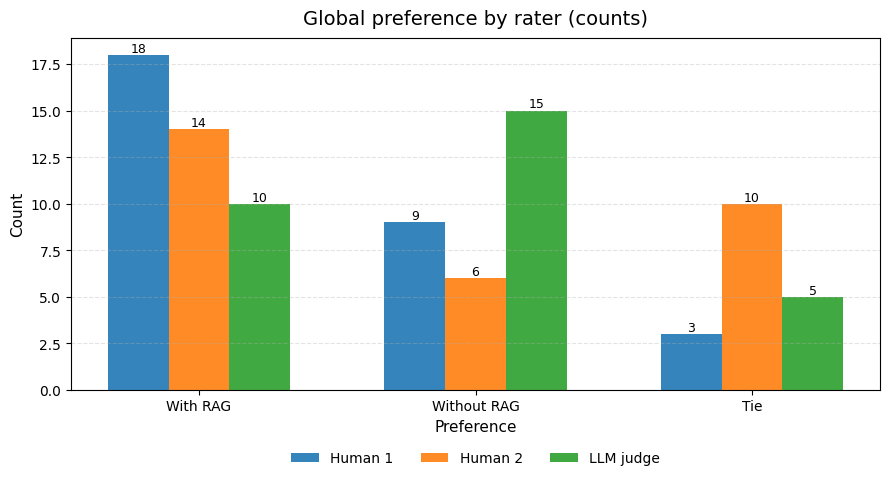

In [70]:
plot_preferencias_por_avaliador(
    resumo_por_avaliador = resumo_por_avaliador,
    value_col="n",
    title="Global preference by rater (counts)"
)

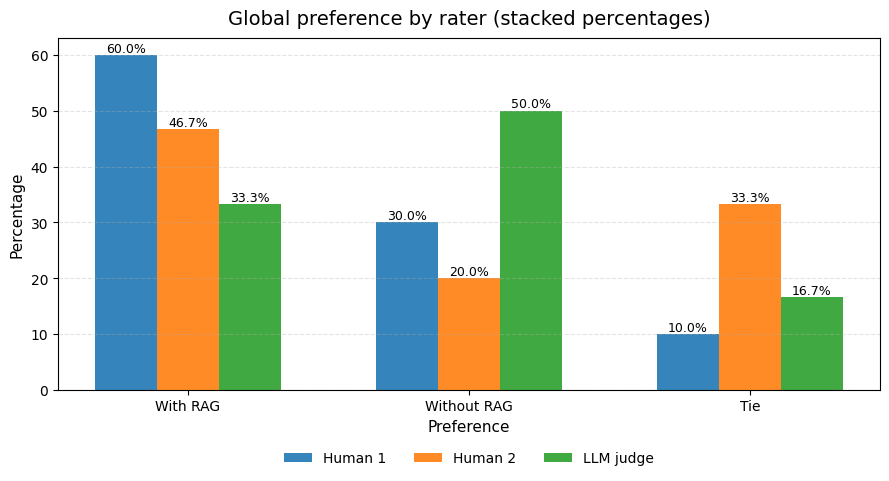

In [71]:
plot_preferencias_por_avaliador(
    resumo_por_avaliador = resumo_por_avaliador,
    value_col="percentage",
    title="Global preference by rater (stacked percentages)"
)

In [72]:
def plot_preferencias_empilhadas(
    resumo_por_avaliador: pd.DataFrame,
    value_col: str = "proportion",  # "n", "proportion", "percentage"
    y_label = "Porcentage",
    x_label = "Rater",
    figsize: tuple = (8, 5),
    title: str = "Global preference by rater",
    title_fontsize: int = 14,
    axis_label_fontsize: int = 11,
    tick_fontsize: int = 10,
    show_values: bool = False,
    preference_order: list[str] | None = None,
    rater_order: list[str] | None = None,
    preference_map: dict | None = None,
    rater_map: dict | None = None,
):
    df = resumo_por_avaliador.copy()

    if preference_order is None:
        preference_order = ["rag_enabled", "rag_disabled", "tie"]

    if rater_order is None:
        rater_order = ["human1_judge", "human2_judge", "llm_judge"]

    if preference_map is None:
        preference_map = {
            "rag_enabled": "With RAG",
            "rag_disabled": "Without RAG",
            "tie": "Tie"
        }

    if rater_map is None:
        rater_map = {
            "human1_judge": "Human 1",
            "human2_judge": "Human 2",
            "llm_judge": "LLM judge"
        }

    df_plot = (
        df.pivot(index="rater", columns="preference_raw", values=value_col)
          .reindex(index=rater_order, columns=preference_order)
    )

    fig, ax = plt.subplots(figsize=figsize)

    bottom = np.zeros(len(df_plot))

    for pref in preference_order:
        vals = df_plot[pref].to_numpy(dtype=float)
        bars = ax.bar(
            [rater_map.get(r, r) for r in df_plot.index],
            vals,
            bottom=bottom,
            label=preference_map.get(pref, pref),
            alpha=0.9
        )

        if show_values:
            for bar, v, b in zip(bars, vals, bottom):
                if pd.notna(v) and v > 0:
                    label = f"{v:.2f}" if value_col == "proportion" else f"{v:.1f}%" if value_col == "percentage" else f"{int(v)}"
                    ax.text(
                        bar.get_x() + bar.get_width() / 2,
                        b + v / 2,
                        label,
                        ha="center",
                        va="center",
                        fontsize=9
                    )

        bottom += np.nan_to_num(vals)

  

    ax.set_ylabel(y_label, fontsize=axis_label_fontsize)
    ax.set_xlabel("Rater", fontsize=axis_label_fontsize)
    ax.set_title(title, fontsize=title_fontsize, pad=10)
    ax.tick_params(axis="x", labelsize=tick_fontsize)
    ax.grid(axis="y", linestyle="--", alpha=0.35)
    ax.legend(title="Preference",loc="lower center", bbox_to_anchor=(0.5, -0.35), ncol=3,frameon=False)

    plt.tight_layout()
    plt.show()

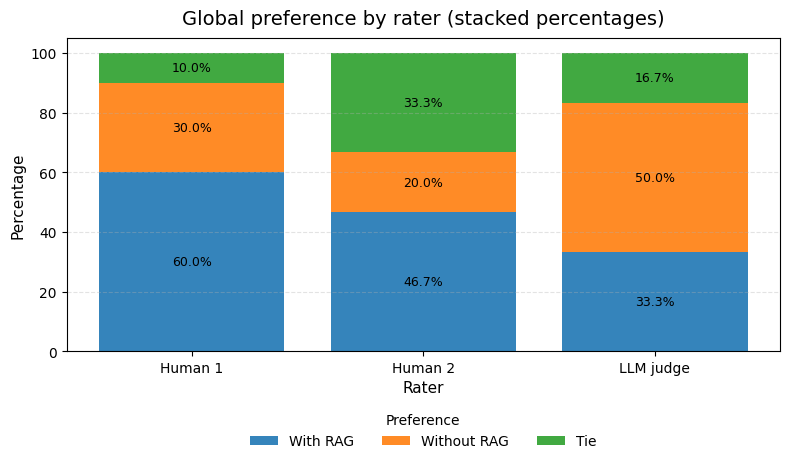

In [73]:
plot_preferencias_empilhadas(
    resumo_por_avaliador = resumo_por_avaliador,
    value_col="percentage",
    y_label = "Percentage",
    x_label = "Rater",
    title="Global preference by rater (stacked percentages)",
    show_values=True
)

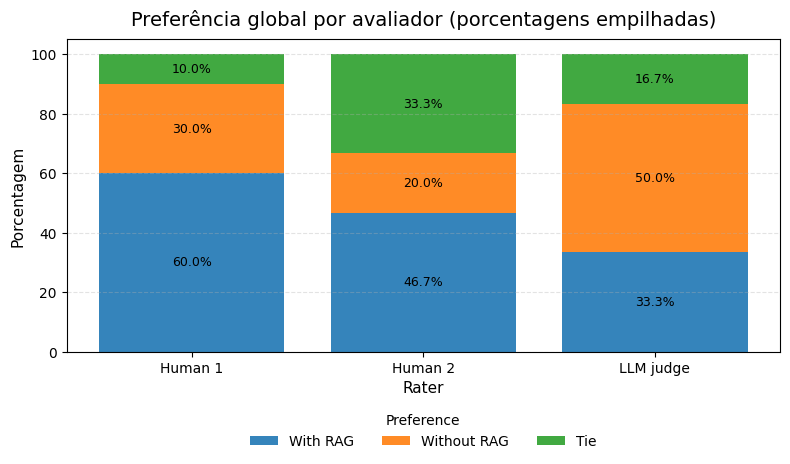

In [74]:
plot_preferencias_empilhadas(
    resumo_por_avaliador = resumo_por_avaliador,
    value_col="percentage",
    y_label = "Porcentagem",
    x_label = "Avaliador",
    title="Preferência global por avaliador (porcentagens empilhadas)",
    show_values=True
)

### BLOCO 2 Inferencias 

In [ ]:
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter
from rpy2.robjects.packages import importr

In [ ]:
base = importr("base")
stats = importr("stats")
nnet = importr("nnet")

In [ ]:
ro.r(
    """
    fit_multinom_pref_py <- function(df_r, formula_str = "preference_raw ~ rater") {

      # referências
      df_r$preference_raw <- stats::relevel(as.factor(df_r$preference_raw), ref = "rag_disabled")
      df_r$rater <- stats::relevel(as.factor(df_r$rater), ref = "human1_judge")
      df_r$question_id <- as.factor(df_r$question_id)

      # modelo nulo e modelo com avaliador
      m0 <- nnet::multinom(preference_raw ~ 1, data = df_r, trace = FALSE, Hess = TRUE)
      m1 <- nnet::multinom(stats::as.formula(formula_str), data = df_r, trace = FALSE, Hess = TRUE)

      sm <- summary(m1)

      coef_mat <- sm$coefficients
      se_mat <- sm$standard.errors

      # garantir formato matricial
      if (is.null(dim(coef_mat))) {
        coef_mat <- matrix(coef_mat, nrow = 1)
        rownames(coef_mat) <- levels(df_r$preference_raw)[-1]
        colnames(coef_mat) <- names(sm$coefficients)
      }

      if (is.null(dim(se_mat))) {
        se_mat <- matrix(se_mat, nrow = 1)
        rownames(se_mat) <- rownames(coef_mat)
        colnames(se_mat) <- colnames(coef_mat)
      }

      coef_df <- as.data.frame(as.table(coef_mat))
      names(coef_df) <- c("comparison", "term", "estimate")

      se_df <- as.data.frame(as.table(se_mat))
      names(se_df) <- c("comparison", "term", "std_error")

      coef_table <- merge(coef_df, se_df, by = c("comparison", "term"), sort = FALSE)

      coef_table$z_value <- coef_table$estimate / coef_table$std_error
      coef_table$p_value <- 2 * stats::pnorm(abs(coef_table$z_value), lower.tail = FALSE)
      coef_table$ci_low <- coef_table$estimate - 1.96 * coef_table$std_error
      coef_table$ci_high <- coef_table$estimate + 1.96 * coef_table$std_error
      coef_table$odds_ratio <- exp(coef_table$estimate)
      coef_table$or_ci_low <- exp(coef_table$ci_low)
      coef_table$or_ci_high <- exp(coef_table$ci_high)

      # LR test: modelo com rater vs nulo
      ll0 <- as.numeric(stats::logLik(m0))
      ll1 <- as.numeric(stats::logLik(m1))
      df0 <- attr(stats::logLik(m0), "df")
      df1 <- attr(stats::logLik(m1), "df")

      lr_stat <- 2 * (ll1 - ll0)
      lr_df <- df1 - df0
      lr_p_value <- stats::pchisq(lr_stat, df = lr_df, lower.tail = FALSE)

      # probabilidades previstas por avaliador
      newdata <- data.frame(
        rater = levels(df_r$rater)
      )

      pred <- predict(m1, newdata = newdata, type = "probs")

      if (is.null(dim(pred))) {
        pred <- matrix(pred, nrow = 1)
        colnames(pred) <- levels(df_r$preference_raw)
      }

      pred_df <- cbind(newdata, as.data.frame(pred))
      rownames(pred_df) <- NULL

      out <- list(
        model = m1,
        coef_table = coef_table,
        pred_table = pred_df,
        fit_stats = data.frame(
          logLik = ll1,
          AIC = stats::AIC(m1),
          nobs = nrow(df_r),
          lr_stat = lr_stat,
          lr_df = lr_df,
          lr_p_value = lr_p_value
        )
      )

      return(out)
    }
    """
)

In [ ]:
def fit_multinom_preference(
    df_pref_long: pd.DataFrame,
    formula: str = "preference_raw ~ rater"
):
    required_cols = {"question_id", "preference_raw", "rater"}
    missing = required_cols - set(df_pref_long.columns)
    if missing:
        raise ValueError(f"Faltam colunas obrigatórias: {sorted(missing)}")

    df = df_pref_long.copy()

    # manter apenas categorias válidas
    df = df[df["preference_raw"].isin(["rag_enabled", "rag_disabled", "tie"])].copy()
    df = df.dropna(subset=["question_id", "preference_raw", "rater"]).copy()

    df["question_id"] = df["question_id"].astype(str)
    df["preference_raw"] = df["preference_raw"].astype(str)
    df["rater"] = df["rater"].astype(str)

    with localconverter(ro.default_converter + pandas2ri.converter):
        df_r = ro.conversion.py2rpy(df)

    fit_fn = ro.globalenv["fit_multinom_pref_py"]
    res = fit_fn(df_r, formula)

    with localconverter(ro.default_converter + pandas2ri.converter):
        coef_table = ro.conversion.rpy2py(res.rx2("coef_table"))
        pred_table = ro.conversion.rpy2py(res.rx2("pred_table"))
        fit_stats = ro.conversion.rpy2py(res.rx2("fit_stats"))

    coef_table = pd.DataFrame(coef_table)
    pred_table = pd.DataFrame(pred_table)
    fit_stats = pd.DataFrame(fit_stats)

    return {
        "model_r": res.rx2("model"),
        "coef_table": coef_table,
        "pred_table": pred_table,
        "fit_stats": fit_stats
    }

In [ ]:
res_multinom = fit_multinom_preference(df_pref_long)



In [ ]:
res_multinom["fit_stats"]

In [ ]:
res_multinom["coef_table"]

In [ ]:
print("Fit stats")
print(res_multinom["fit_stats"])



Como p-valor foi significativo, entao a distribuicao de preferencias varia entre os avaliadores.

In [ ]:
print("\nCoeficientes")
res_multinom["coef_table"]



In [ ]:
print("\nProbabilidades previstas por avaliador")
res_multinom["pred_table"]

Para o avaliador 1 temos que 60% das vezes ele prefere a resposta com RAG e apenas 10% empates. Agora para o avaliador 2 ainda preferen o rag, e  empata em 33% dos casos, agora para a LLM Judge em 50% dos casos prefere a resposta sem RAG. (IGUAL AS FREQUENCIAS)

#### Vamos fazer uma analise de sensibilidade.

In [ ]:
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter
from rpy2.robjects.packages import importr

In [ ]:
base = importr("base")
stats = importr("stats")
mclogit = importr("mclogit")

In [ ]:
ro.r(r"""
fit_mblogit_pref_py <- function(
  df_r,
  formula_str = "preference_raw ~ rater",
  random_str = "~ 1 | question_id",
  method = "PQL",
  catCov = "single"
) {

  df_r$preference_raw <- stats::relevel(as.factor(df_r$preference_raw), ref = "rag_disabled")
  df_r$rater <- stats::relevel(as.factor(df_r$rater), ref = "human1_judge")
  df_r$question_id <- as.factor(df_r$question_id)

  f_fixed <- stats::as.formula(formula_str)
  f_random <- stats::as.formula(random_str)

  m0 <- mclogit::mblogit(
    formula = preference_raw ~ 1,
    random = f_random,
    data = df_r,
    method = method,
    catCov = catCov
  )

  m1 <- mclogit::mblogit(
    formula = f_fixed,
    random = f_random,
    data = df_r,
    method = method,
    catCov = catCov
  )

  sm <- summary(m1)

  coef_mat <- sm$coefficients
  coef_df <- as.data.frame(coef_mat)
  coef_df$param <- rownames(coef_mat)
  rownames(coef_df) <- NULL

  coef_df$comparison <- sub("~.*$", "", coef_df$param)
  coef_df$term <- sub("^[^~]*~", "", coef_df$param)

  # renomeação por posição, evitando regex problemática
  base_cols <- names(coef_df)[1:4]
  names(coef_df)[match(base_cols, names(coef_df))] <- c(
    "estimate", "std_error", "z_value", "p_value"
  )

  coef_df$ci_low <- coef_df$estimate - 1.96 * coef_df$std_error
  coef_df$ci_high <- coef_df$estimate + 1.96 * coef_df$std_error
  coef_df$odds_ratio <- exp(coef_df$estimate)
  coef_df$or_ci_low <- exp(coef_df$ci_low)
  coef_df$or_ci_high <- exp(coef_df$ci_high)

  coef_df <- coef_df[, c(
    "comparison", "term", "estimate", "std_error", "z_value", "p_value",
    "ci_low", "ci_high", "odds_ratio", "or_ci_low", "or_ci_high"
  )]

  ll0 <- as.numeric(stats::logLik(m0))
  ll1 <- as.numeric(stats::logLik(m1))
  df0 <- attr(stats::logLik(m0), "df")
  df1 <- attr(stats::logLik(m1), "df")

  lr_stat <- 2 * (ll1 - ll0)
  lr_df <- df1 - df0
  lr_p_value <- stats::pchisq(lr_stat, df = lr_df, lower.tail = FALSE)

  fit_stats <- data.frame(
    logLik = ll1,
    AIC = stats::AIC(m1),
    nobs = nrow(df_r),
    lr_stat = lr_stat,
    lr_df = lr_df,
    lr_p_value = lr_p_value
  )

  out <- list(
    model = m1,
    coef_table = coef_df,
    fit_stats = fit_stats
  )

  return(out)
}
""")

In [ ]:
def fit_mblogit_preference(
    df_pref_long: pd.DataFrame,
    formula: str = "preference_raw ~ rater",
    random: str = "~ 1 | question_id",
    method: str = "PQL",
    catCov: str = "single"
):
    required_cols = {"question_id", "preference_raw", "rater"}
    missing = required_cols - set(df_pref_long.columns)
    if missing:
        raise ValueError(f"Faltam colunas obrigatórias: {sorted(missing)}")

    df = df_pref_long.copy()
    df = df[df["preference_raw"].isin(["rag_enabled", "rag_disabled", "tie"])].copy()
    df = df.dropna(subset=["question_id", "preference_raw", "rater"]).copy()

    df["question_id"] = df["question_id"].astype(str)
    df["preference_raw"] = df["preference_raw"].astype(str)
    df["rater"] = df["rater"].astype(str)

    with localconverter(ro.default_converter + pandas2ri.converter):
        df_r = ro.conversion.py2rpy(df)

    fit_fn = ro.globalenv["fit_mblogit_pref_py"]
    res = fit_fn(df_r, formula, random, method, catCov)

    with localconverter(ro.default_converter + pandas2ri.converter):
        coef_table = ro.conversion.rpy2py(res.rx2("coef_table"))
        fit_stats = ro.conversion.rpy2py(res.rx2("fit_stats"))

    return {
        "model_r": res.rx2("model"),
        "coef_table": pd.DataFrame(coef_table),
        "fit_stats": pd.DataFrame(fit_stats)
    }

In [ ]:
res_mblogit = fit_mblogit_preference(
    df_pref_long,
    formula="preference_raw ~ rater",
    random="~ 1 | question_id",
    method="PQL",
    catCov="single"
)



In [ ]:
res_mblogit["fit_stats"]

In [ ]:
res_mblogit["coef_table"]

#### Resultados

#### Preferência global entre respostas com e sem RAG

Para analisar a preferência global final entre as respostas **WITH RAG**, **WITHOUT RAG** e **tie**, ajustamos inicialmente um modelo de regressão logística multinomial, utilizando `rag_disabled` como categoria de referência e `human1_judge` como avaliador de referência. O teste global do modelo indicou que a distribuição das preferências variou significativamente em função do avaliador (LR = 10.69, df = 4, p = 0.030), sugerindo que a escolha final entre as três categorias não foi homogênea entre os juízes.

No contraste **`rag_enabled` versus `rag_disabled`**, o intercepto do modelo foi positivo (estimate = 0.693; OR = 2.00; IC95% [0.90, 4.45]; p = 0.090), indicando que, para o avaliador de referência (`human1_judge`), a preferência por respostas com RAG tendeu a ser mais frequente do que a preferência por respostas sem RAG, embora sem evidência estatística clara no nível convencional. Em relação a esse avaliador de referência, o **`human2_judge`** não apresentou diferença relevante nesse contraste (estimate = 0.154; OR = 1.17; IC95% [0.34, 4.06]; p = 0.809), sugerindo padrão semelhante entre os dois revisores humanos quanto à escolha direta entre respostas com e sem RAG. Em contraste, o **`llm_judge`** apresentou coeficiente negativo e de magnitude substantiva (estimate = -1.099; OR = 0.33; IC95% [0.11, 1.03]; p = 0.057), indicando tendência a ser menos favorável ao RAG do que o avaliador humano de referência.

No contraste **`tie` versus `rag_disabled`**, o intercepto foi negativo (estimate = -1.099; OR = 0.33; IC95% [0.09, 1.23]; p = 0.099), sugerindo que, para o `human1_judge`, a ocorrência de empate foi menos frequente do que a preferência por `rag_disabled`. O **`human2_judge`**, por sua vez, apresentou um aumento expressivo na razão entre `tie` e `rag_disabled` em comparação ao avaliador de referência (estimate = 1.609; OR = 5.00; IC95% [0.96, 26.11]; p = 0.056), sugerindo maior propensão a registrar empate em vez de escolher explicitamente a condição sem RAG. Já o **`llm_judge`** não diferiu do `human1_judge` nesse contraste (estimate ≈ 0; OR = 1.00; IC95% [0.19, 5.22]; p = 1.000), indicando padrão semelhante entre esses dois avaliadores na relação entre empate e preferência por `rag_disabled`.

Como análise de sensibilidade, ajustamos um modelo multinomial com intercepto aleatório por pergunta (`question_id`), buscando considerar explicitamente o agrupamento das avaliações por item. Os coeficientes e erros-padrão desse modelo foram praticamente idênticos aos obtidos no modelo multinomial principal. Em particular, mantiveram-se: (i) a ausência de diferença relevante entre os dois revisores humanos no contraste `rag_enabled` versus `rag_disabled`; (ii) a tendência do `llm_judge` a ser menos favorável ao RAG do que o avaliador humano de referência; e (iii) a maior propensão do `human2_judge` a registrar empates. Embora estatísticas globais baseadas em verossimilhança não tenham se mostrado informativas nesse modelo de sensibilidade, a estabilidade dos efeitos fixos sugere que as conclusões substantivas não foram alteradas pela introdução do agrupamento por pergunta.

Em síntese, a análise da preferência global mostrou que o avaliador exerce papel relevante na decisão final entre respostas com RAG, sem RAG e empate. Enquanto os revisores humanos apresentaram padrão relativamente próximo no contraste direto entre `rag_enabled` e `rag_disabled`, o `llm_judge` mostrou-se menos propenso a favorecer respostas com RAG. Além disso, o `human2_judge` destacou-se por maior frequência relativa de empates.

#### Discussão

Os resultados da preferência global reforçam a principal leitura emergente das análises por dimensão: **a conclusão sobre a superioridade relativa das respostas depende materialmente de quem avalia**. Embora o modelo multinomial não tenha mostrado diferença relevante entre os dois avaliadores humanos no contraste direto entre `rag_enabled` e `rag_disabled`, ambos permaneceram substancialmente distintos do `llm_judge`, que apresentou menor inclinação a favorecer respostas com RAG. Esse resultado é consistente com a análise anterior por CLMM, na qual o juiz automatizado também não acompanhou o padrão mais favorável ao RAG observado entre os especialistas humanos.

Ao mesmo tempo, a variável de preferência global acrescenta uma nuance importante que não era totalmente capturada pelas avaliações dimensionais: a presença de uma categoria explícita de **empate**. Nesse ponto, o `human2_judge` apresentou comportamento distinto do `human1_judge`, com maior propensão a declarar `tie` em vez de optar diretamente por `rag_disabled`. Esse achado sugere que a divergência entre avaliadores não se resume à direção da preferência, mas também ao **estilo de decisão**. Enquanto um avaliador parece mais disposto a produzir um julgamento comparativo categórico, o outro parece adotar uma postura mais cautelosa, recorrendo com maior frequência ao empate quando a superioridade de uma condição não se mostra suficientemente clara.

Esse padrão tem implicações metodológicas importantes. Em primeiro lugar, ele mostra que a variável de preferência global não deve ser tratada como mera simplificação binária da avaliação. A presença de `tie` carrega informação substantiva sobre incerteza, conservadorismo decisório ou ausência de diferença percebida entre as condições. Em segundo lugar, ele reforça a cautela necessária na interpretação de **LLM-as-a-judge** em tarefas comparativas. O fato de o `llm_judge` tender menos a escolher `rag_enabled` do que o avaliador humano de referência sugere que o modelo automatizado pode estar priorizando atributos diferentes daqueles valorizados pelos especialistas humanos ao emitir uma decisão final.

A análise de sensibilidade com intercepto aleatório por pergunta fortalece essa interpretação. Mesmo após considerar explicitamente o agrupamento das avaliações no nível do item, os coeficientes permaneceram praticamente inalterados em relação ao modelo multinomial principal. Isso sugere que a diferença entre avaliadores não é um artefato simples de dependência entre observações da mesma pergunta, mas reflete um padrão substantivo de julgamento. Em outras palavras, a divergência observada entre os avaliadores parece robusta à mudança de especificação do modelo.

Em conjunto, esses resultados ampliam a narrativa construída nas análises anteriores. As dimensões Likert já indicavam que os humanos tendiam a perceber ganhos com o RAG em maior grau do que o juiz automatizado. A análise de preferência global mostra que essa divergência persiste mesmo quando a tarefa é reduzida a uma decisão comparativa final. Além disso, ela revela uma camada adicional de heterogeneidade entre os próprios humanos, expressa pelo uso diferencial da categoria de empate. Assim, o estudo não apenas compara respostas com e sem RAG, mas também evidencia que a avaliação de sua efetividade é fortemente condicionada ao perfil, critérios e estilo decisório do avaliador.


##### Versão mais curta para a discussão

A análise da preferência global confirmou que a decisão final entre respostas com RAG, sem RAG e empate varia em função do avaliador. O `llm_judge` mostrou-se menos propenso a favorecer respostas com RAG do que o avaliador humano de referência, enquanto o `human2_judge` se destacou pelo uso mais frequente de `tie`. A análise de sensibilidade com intercepto aleatório por pergunta preservou praticamente os mesmos efeitos fixos, sugerindo que esse padrão não decorre apenas da estrutura agrupada dos dados. Em conjunto, os resultados reforçam que a avaliação da efetividade do RAG depende materialmente de quem avalia e de como esse avaliador lida com situações de incerteza comparativa.
